In [26]:
### Will use AtlasOpenMagic package to download data and MC files and reconstruct Higgs peak
import numpy as np
import matplotlib.pyplot as plt
import uproot
import awkward as ak
import time
import atlasopenmagic as atom
import vector as v
from matplotlib.ticker import AutoMinorLocator # for minor ticks
import itertools

# Notes on ATLAS open data files 

The metadata table of the various samples is found here
https://opendata.atlas.cern/docs/data/for_education/13TeV25_metadata

Notes on background processes:
The ZZ background is the largest and irreducible because pp->ZZ->4l has same signature as H->ZZ->4l

Z+jets: event is pp-> Z + jets, Z decays to 2l and the two heavy-flavor jets decay semileptonically (produce one lepton). occasionally both heavy quarks produce isolated leps
the Z+jets cross section is large so some surviving events produce a meaningful BG

ttbar: process is pp->tt*, t->Wb. if both W decay leptonically and both b quarks decay leptonically, can have 4l, sometimes pass iso cuts
even though the prob of 4l decay is small, large cross sec produces some events

ttbar + V: same as above, tt* can produce two leps, if V decays leptonically we have 3l even without quark

VVV: W->lv, Z->ll, multiple permutations of 3 bosons can produce 4+ leps


In [3]:
#atom.available_releases()
atom.set_release("2025e-13tev-beta")
skim = '4lep'

# the DIDs were taken from the metadata table linked above
# this dictionary will hold the data for each of the different samples
data_keys = {
    r'Data': {
        'dids': ['data']
    },

    r'Background $Z+\mathrm{jets}$': {
        'dids': [
            700320, 700321, 700322,
            700323, 700324, 700325
        ],
        'color': "#c49c94"
    },

    r'Background $t\bar{t}$': {
        'dids': [
            410470
        ],
        'color': "#1f77b4"
    },

    r'Background $t\bar{t}+V$': {
        'dids': [
            410155,
            410218,
            410219,
            412043
        ],
        'color': "#ff7f0e"
    },

    r'Background $VVV$': {
        'dids': [
            364242,
            364243,
            364246,
            364248
        ],
        'color': "#2ca02c"
    },

    r'Background $ZZ^{*}$': {
        'dids': [700600],
        'color': "#ff0000"
    },

    r'Signal ($m_H$ = 125 GeV)': {
        'dids': [
            345060,
            346228,
            346310,
            346311,
            346312,
            346340,
            346341,
            346342
        ],
        'color': "#00cdff"
    }
}

allsamples = atom.build_dataset(data_keys, skim = skim,protocol = 'https', cache = True)

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 1052.79datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


# Function definitions for cuts + calculations

Here I define the cuts
1) Ensure 4 leptons
2) Ensure that the event passes either the mass or energy trigger
3) Ensure that the lepton being triggered on is one of the 4 leptons used for the mass reconstruction analysis
4) Ensure that every lepton in the event is isolated (didn't come from a jet, not too much other activity around it) and identified as the correct particle type. Note that most of the non-ZZ* background events involve jets that pass this cut
5) Tranverse momentum cut, requirements on each particle. These will be varied as a later study
6) Cut on total charge of the leptons - the 4l process should have two pairs of oppositely charged particles
7) Lep type cut - make sure we have two particle-antiparticle pairs

The mass is calculated by using the vector library M() function, which will calculate the invariant mass with $$m = \sqrt{E^2 - |\vec{x}^2|}$$

In [ ]:
# write functions for making cuts
variables = ['num_events','lep_pt','lep_eta','lep_phi','lep_e','lep_n','lep_charge','lep_type',
             'trigE','trigM','lep_isTrigMatched','lep_isLooseID','lep_isMediumID','lep_isLooseIso']

# cut on num leptons
# if true, keep event
def cut_lep_n(lep_n):
    cutboolarray = (lep_n == 4)
    return cutboolarray

# check if the event was triggered on either mass or energy
# if the event passes cut, return true
def cut_trigger(trigE,trigM):
    cutboolarray = trigE | trigM
    return (cutboolarray)

# trigmatch is awk array, each entry corresponds to an event
# each entry is a list of booleans for each lepton and whether it was triggered on
# ensure that at least one of the leptons in the event was triggered on
# returns a bool array, true if the event passes cut
# the ak.sum(axis=1) means we sum the boolean values in each event (sum columns/lepton bool values of each event row)
def cut_trigger_match(trigmatch):
    cutboolarray = (ak.sum(trigmatch,axis=1) >= 1) #1 is True, 0 is False
    return cutboolarray

# now check to make sure that every lepton in the event is isolated + identified
# if electron, check identified as electron and isolated, same with muon
# note that lep num cut must already be applied
def cut_ID_iso(pid,id_e,iso_e,id_mu,iso_mu):
    #if all 4 leptons are electron, identified, isolated, return True
    # also return True if we have 2mu, 2e
    # do this by 
    cut_earray = ak.sum((id_e & (pid == 11) & iso_e),axis=1) 
    cut_muarray = ak.sum((id_mu & (pid == 13) & iso_mu),axis=1)

    boolarray_4e_or4mu = (cut_earray | cut_muarray) == 4
    boolarray_2e       = (cut_earray == 2) 
    boolarray_2mu      = (cut_muarray ==2)

    # if event passes either muon or electron cut, return True
    return (boolarray_4e_or4mu | (boolarray_2e & boolarray_2mu))

# cut on pT
# these cuts can later be varied
# requirements: 1st particle pt > 20gev, 2nd > 15Gev, 3rd > 10GeV
def cut_pt(lep_pt):
    pt1 = lep_pt[:,0]
    pt2 = lep_pt[:,1]
    pt3 = lep_pt[:,2]
    pt1cut = pt1 > 20 # GeV
    pt2cut = pt2 > 15 
    pt3cut = pt3 > 10
    return (pt1cut & pt2cut & pt3cut)

# now cut on lep charge
# H->4l process must produce two pairs of oppositely charged leps, total charge = 0
# if true, event passes
# note that these next two cuts are do not fully catch SFOS pairs, upgraded in Z1/Z2 cuts below
def cut_lep_charge(lep_charge):
    cutboolarray = (ak.sum(lep_charge,axis = 1) == 0)
    return cutboolarray

# ensure that the event returned either 4mu, 4e, or 2mu+2e
def cut_lep_type(lep_type):
    #each entry of lep_type is an array of the pids of the leptons inside
    pidsum = ak.sum(lep_type,axis=1)
    is4e = pidsum == 11*4
    is4mu = pidsum == 13*4
    is2e2mu = pidsum == 11*2+13*2
    cutboolarray = is4e | is4mu | is2e2mu
    return cutboolarray

def calc_mass(pt,eta,phi,E):
    # first create a 4vec for each of the particles
    p4 = v.zip({"pt":pt,"eta":eta,"phi":phi,"E":E})
    p4_sum = p4[:,0] + p4[:,1] + p4[:,2] + p4[:,3]
    M = p4_sum.M
    return M

# this one is only used in the Z1/Z2 reconstruction
def calc_mass_2particles_old(pt,eta,phi,E):
    # first create a 4vec for each of the particles
    p4 = v.zip({"pt":pt,"eta":eta,"phi":phi,"E":E})
    # note that these 4-mom vectors are are indexed with one index instead of a slice
    # because this function is used per event and not vectorized
    p4_sum = p4[0] + p4[1]
    M = p4_sum.M
    return M

# this is faster than constructing vector objects
def calc_mass_2particles(pt, eta, phi, E):
    px = pt[0]*np.cos(phi[0]) + pt[1]*np.cos(phi[1])
    py = pt[0]*np.sin(phi[0]) + pt[1]*np.sin(phi[1])
    pz = pt[0]*np.sinh(eta[0]) + pt[1]*np.sinh(eta[1])
    Esum = E[0] + E[1]
    m2 = Esum**2 - px**2 - py**2 - pz**2
    return np.sqrt(max(m2, 0))

# Notes on upgrading cuts to include Z1/Z2 SFOS pair reconstruction

Current implementation / first draft only checked for 4l SFOS by checking that the total charge = 0 and that we had either 2mu2e or 4e or 4mu. This lets in background events where we have, for example, 2mu- and 2e+. 

Also in events with 2e+,2e-, there are two ways to pair the 3 SFOS pairs into valid Z1/Z2 pairs. One combination would give the correct result: one pair with mass near 91GeV (the on shell Z1) and the other with low mass, but the other pairing could give two pairs with intermediate mass. The first draft analysis based on the tutorial doesn't account for this, we just sum all four leptons regardless of the pairing. The real ATLAS analysis picks the pairing that maximizes consistency with ZZ* decay.

Note that the Z1 spread has contributions from both the detector uncertainty and the intrinsic Z width from energy-time unc. principle.

Note: while the other cuts are done vectorized, the Z1Z2 cuts will need to be done on a loop over events because the Z1/Z2 reconstruction logic requires a variable number of operations per event

Here is the implementation strategy for the upgraded reconstruction alg:
1) find all SFOS pairs: identify every combo of 2e or 2mu AND opposite sign
- there are 3 valid pairs in 4mu/e event, only one valid pair in 2mu2e event
2) Find valid combinations of SFOS pairs into the (Z1, Z2)
3) for each valid pairing, calc mass with vector.M()
4) apply Z mass window cuts to both pairs
- official ATLAS selection requires 50 GeV $< m_{Z1} < 106$ GeV and 12 GeV $< m_{Z2} < 115$ GeV.
5) If multiple pairings survive (only possible in 4e/4mu case), pick pair with $m_{Z1}$ closest to 91.2 GeV

function should return bool for if valid pair exists, plus Z1/Z2 masses
use itertools.combinations(range(4),2) to get all 6 index pairs
filter for SFOS, form the complementary pairs, apply mass window cuts, then rank

use python loop over leptons within an event

In [110]:
def cut_Z1Z2(lep_pt,lep_eta,lep_phi,lep_E,lep_charge,lep_type):
    # each of these tuples represents the two indices (in the list of 4 leptons) of a possible SFOS pair
    tuplelist_allleps = itertools.combinations(range(4),2) # [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
    sfos_pairs = []
    mz = 91.2

    for j,tuple in enumerate(tuplelist_allleps):
        # check if the pair has opposite charge and same flavor
        # need to check that the lep type 
        leptypecheck = lep_type[tuple[0]] == lep_type[tuple[1]]
        lepchargecheck = (lep_charge[tuple[0]] == (-1 * lep_charge[tuple[1]]))
        if leptypecheck & lepchargecheck:
            sfos_pairs.append(tuple)

    # cut event if we don't have 2 good pairs
    if len(sfos_pairs) < 2: 
        return False, 9999, 9999

    # sfos_pairs should either have 2 entries (2e2mu events) or 3 entries (4e/4mu events)
    # for the 2e2mu case, i only have 1 way to partition the 4l into non-overlapping SFOS pairs
    # but for the 4e or 4mu case, i have 2 ways to partition into non-overalpping z1/z2 pairs

    # we need to now find non-overlapping pairings
    # find all pairs-of-pairs where no lepton index appears twice
    combolist_sfospairs = itertools.combinations(sfos_pairs,2)
    candidate_pairings = []
    for combo in combolist_sfospairs:
        # add the two tuples together 
        pooled_indices_repeats = combo[0] + combo[1]
        # create a set (no repeated values)
        pooled_indices = set(pooled_indices_repeats)
        if len(pooled_indices) == 4:
            candidate_pairings.append(combo)
    
    # now candidate pairings should have 1 entry (2mu2e case) or 2 entries (4e/4mu case)
    # each entry is a list of 2 tuples of size 2 (two indices)
    
    mz1_list = []
    mz2_list = []
    # now loop over combos in combolist and pick the best combination (out of either 1 or 2)
    for p in candidate_pairings:
        # the coordinates should be a list of the values for the two leptons
        #lep_pt[p[0][0]] gives the pt of the first lepton in the first pair in THIS pairing
        pt_pair1  = [lep_pt[p[0][0]],lep_pt[p[0][1]]] 
        eta_pair1 = [lep_eta[p[0][0]],lep_eta[p[0][1]]]
        phi_pair1 = [lep_phi[p[0][0]],lep_phi[p[0][1]]]
        E_pair1 = [lep_E[p[0][0]],lep_E[p[0][1]]]

        pt_pair2  = [lep_pt[p[1][0]],lep_pt[p[1][1]]] 
        eta_pair2 = [lep_eta[p[1][0]],lep_eta[p[1][1]]]
        phi_pair2 = [lep_phi[p[1][0]],lep_phi[p[1][1]]]
        E_pair2   = [lep_E[p[1][0]],lep_E[p[1][1]]]

        # calculate mass for each pair
        m1 = calc_mass_2particles(pt_pair1,eta_pair1,phi_pair1,E_pair1)
        m2 = calc_mass_2particles(pt_pair2,eta_pair2,phi_pair2,E_pair2)
        
        # check which pair has mass closer to 91.2 GeV
        m1vsmz = abs(m1 - mz)
        m2vsmz = abs(m2 - mz)
        # assign Z1/Z2 based on which mass is closer to Z1 on shell mass
        if m1vsmz < m2vsmz:
            mz1 = m1
            mz2 = m2
        else:
            mz1 = m2
            mz2 = m1
        # cut on Z1/Z2 mass windows
        if not ((mz1 < 50) | (mz1 > 106) | (mz2  < 12) | (mz2 > 115)):
            mz1_list.append(mz1)
            mz2_list.append(mz2)   

    if len(mz1_list) == 0: 
        cutbool = False #cut event
        mz1_final = 9999 # as flag something went wrong
        mz2_final = 9999
    elif len(mz1_list) == 1: 
        cutbool = True #pass event
        mz1_final = mz1_list[0]
        mz2_final = mz2_list[0]
    elif len(mz1_list) == 2:
        cutbool = True
        # if both candidate pairings pass mass window, pick the one with mz1 closest to 91.2 GeV
        if abs(mz - mz1_list[0]) < abs(mz - mz1_list[1]): 
            mz1_final = mz1_list[0]
            mz2_final = mz2_list[0]
        else:
            mz1_final = mz1_list[1]
            mz2_final = mz2_list[1]
    else: print(f"Error: mz1_list doesn't have correct num entries. Num entries + {len(mz1_list)}")
    #print(f'pass event: {cutbool}, {mz1 = }, {mz2 = }')
    return (cutbool,mz1_final,mz2_final)
    


In [111]:
# now examine one data file to ensure cuts are working properly
print("First data sample: " + str(allsamples['Data']['list'][0]))
# open the file, the tree is named analysis
file1 = uproot.open(allsamples['Data']['list'][0])
tree1 = file1['analysis']

# loop over iterated tree, check to see what the distribution of lep num is
lepnumarray =[]

#create awk array for surviving data
data_s = []

for data in tree1.iterate(variables,library='ak'):
    for lepnum in data['lep_n']:
    # use to make a quick histo of the lepnum
        lepnumarray.append(lepnum)

    # do cuts on the data file
    print("Num events before cuts: "+str(len(data)))

    # the cuts are vectorized for effiency
    # each cut passes a bool array back to the data ak array
    # for all events with False in the bool array, the event is tossed

    data = data[cut_lep_n(data['lep_n'])]
    print("Num events after lep_n cuts: "+str(len(data)))

    data = data[cut_trigger(data['trigE'],data['trigM'])]
    data = data[cut_trigger_match(data['lep_isTrigMatched'])]
    print("Num events after trigger cuts: "+str(len(data)))

    # use histo the lep pid sums to check cut_lep_type function
    pidsum_aftrigcut = ak.sum(data['lep_type'],axis=1) 

    data = data[cut_pt(data['lep_pt'])]
    print("Num events after pt cuts: "+str(len(data)))

    # use histo the lep pid sums to check cut_lep_type function
    pidsum_afptcut = ak.sum(data['lep_type'],axis=1) 

    # electron should have loose ID, ID comes from ecal
    # muon should have medium ID (atlas recommendation?)
    # both should have loose iso criteria
    # inputs are pid,id_e,iso_e,id_mu,iso_mu
    data = data[cut_ID_iso(data['lep_type'],data['lep_isLooseID'],
                data['lep_isLooseIso'],data['lep_isMediumID'],
                data['lep_isLooseIso'])]
    print("Num events after ID iso cuts: "+str(len(data)))

    data = data[cut_lep_charge(data['lep_charge'])]
    print("Num events after lep charge cuts: "+str(len(data)))
    
    data = data[cut_lep_type(data['lep_type'])]
    print("Num events after lep type cuts: "+str(len(data)))

    # use histo the lep pid sums to check cut_lep_type function
    pidsum_aftypecut = ak.sum(data['lep_type'],axis=1) 

    #calculate mass
    data['mass'] = calc_mass(data['lep_pt'],data['lep_eta'],data['lep_phi'],data['lep_e'])
    print(data['mass'])
    data_s.append(data)

# data_s is a list with 1 entry, the array with all the data
# this array has len num surviving events
print(len(data_s[0]))

mz = 91.2
# now loop over surviving events to do the Z1/Z2 cuts
for i,event in enumerate(data_s[0]):
    print(f'\n doing Z1Z2 tests for event {i}')
    print('lep charges: ' + str(event['lep_charge']))
    print('lep types: '   + str(event['lep_type']))

    lep_pt     = ak.to_numpy(event['lep_pt'])
    print(f'pt: {lep_pt}')
    lep_eta    = ak.to_numpy(event['lep_eta'])
    lep_phi    = ak.to_numpy(event['lep_phi'])
    lep_E      = ak.to_numpy(event['lep_e'])
    lep_type   = ak.to_numpy(event['lep_type'])
    lep_charge = ak.to_numpy(event['lep_charge'])

    # each of these tuples represents the two indices (in the list of 4 leptons) of a possible SFOS pair
    tuplelist_allleps = itertools.combinations(range(4),2) # [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
    sfos_pairs = []

    print(tuplelist_allleps)
    for j,tuple in enumerate(tuplelist_allleps):
        print(f"tuple index: {j}")
        # check if the pair has opposite charge and same flavor
        # need to check that the lep type 
        leptypecheck = lep_type[tuple[0]] == lep_type[tuple[1]]
        print("leptypecheck:" + str(leptypecheck))
        lepchargecheck = (lep_charge[tuple[0]] == (-1 * lep_charge[tuple[1]]))
        print("lepchargecheck:" + str(lepchargecheck))
        if leptypecheck & lepchargecheck:
            sfos_pairs.append(tuple)
    print("sfos pairs:")
    print(sfos_pairs)
    # cut event if we don't have 2 good pairs
    if len(sfos_pairs) < 2: cutbool = False

    # sfos_pairs should either have 2 entries (2e2mu events) or 3 entries (4e/4mu events)
    # for the 2e2mu case, i only have 1 way to partition the 4l into non-overlapping SFOS pairs
    # but for the 4e or 4mu case, i have 2 ways to partition into non-overalpping z1/z2 pairs

    # we need to now find non-overlapping pairings
    # find all pairs-of-pairs where no lepton index appears twice
    combolist_sfospairs = itertools.combinations(sfos_pairs,2)
    candidate_pairings = []
    for combo in combolist_sfospairs:
        # add the two tuples together 
        pooled_indices_repeats = combo[0] + combo[1]
        # create a set (no repeated values)
        pooled_indices = set(pooled_indices_repeats)
        if len(pooled_indices) == 4:
            candidate_pairings.append(combo)
    print("candidate pairs:")
    print(candidate_pairings)

    # now candidate pairings should have 1 entry (2mu2e case) or 2 entries (4e/4mu case)
    # each entry is a list of 2 tuples of size 2 (two indices)
    
    mz1_list = []
    mz2_list = []
    # now loop over combos in combolist and pick the best combination (out of either 1 or 2)
    for p in candidate_pairings:
        print("\n this pairing: "+str(p))
        # the coordinates should be a list of the values for the two leptons
        #lep_pt[p[0][0]] gives the pt of the first lepton in the first pair in THIS pairing
        pt_pair1  = [lep_pt[p[0][0]],lep_pt[p[0][1]]] 
        eta_pair1 = [lep_eta[p[0][0]],lep_eta[p[0][1]]]
        phi_pair1 = [lep_phi[p[0][0]],lep_phi[p[0][1]]]
        E_pair1 = [lep_E[p[0][0]],lep_E[p[0][1]]]

        pt_pair2  = [lep_pt[p[1][0]],lep_pt[p[1][1]]] 
        eta_pair2 = [lep_eta[p[1][0]],lep_eta[p[1][1]]]
        phi_pair2 = [lep_phi[p[1][0]],lep_phi[p[1][1]]]
        E_pair2   = [lep_E[p[1][0]],lep_E[p[1][1]]]

        print(f'pt_pair1: {pt_pair1}')

        # calculate mass for each pair
        # debugging mass fxn
        #p4 = v.zip({"pt":pt_pair1,"eta":eta_pair1,"phi":phi_pair1,"E":E_pair1})
        #print('p4'+str(p4))
        #p4_sum = p4[0] + p4[1]
        #print('p4_sum: ' + str(p4_sum))
        #m1 = p4_sum.M
        #print('m1: '+str(m1))
        m1 = calc_mass_2particles(pt_pair1,eta_pair1,phi_pair1,E_pair1)
        m2 = calc_mass_2particles(pt_pair2,eta_pair2,phi_pair2,E_pair2)
        print(f'm1: {m1}, m2: {m2}')
        
        # check which pair has mass closer to 91.2 GeV
        m1vsmz = abs(m1 - mz)
        m2vsmz = abs(m2 - mz)
        # assign Z1/Z2 based on which mass is closer to Z1 on shell mass
        if m1vsmz < m2vsmz:
            mz1 = m1
            mz2 = m2
        else:
            mz1 = m2
            mz2 = m1
        # cut on Z1/Z2 mass windows
        if not ((mz1 < 50) | (mz1 > 106) | (mz2  < 12) | (mz2 > 115)):
            mz1_list.append(mz1)
            mz2_list.append(mz2)
            
    if len(mz1_list) == 0: cutbool = False #cut event
    elif len(mz1_list) == 1: 
        cutbool = True #pass event
        mz1_final = mz1_list[0]
        mz2_final = mz2_list[0]
    elif len(mz1_list) == 2:
        cutbool = True
        # if both candidate pairings pass mass window, pick the one with mz1 closest to 91.2 GeV
        if abs(mz - mz1_list[0]) < abs(mz - mz1_list[1]): 
            mz1_final = mz1_list[0]
            mz2_final = mz2_list[0]
        else:
            mz1_final = mz1_list[1]
            mz2_final = mz2_list[1]
    else: print(f"Error: mz1_list doesn't have correct num entries. Num entries + {len(mz1_list)}")
    print(f'pass event: {cutbool}, {mz1 = }, {mz2 = }')
    #return (cutbool,mz1_final,mz2_final)
    


First data sample: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodD.4lep.root
Num events before cuts: 3708
Num events after lep_n cuts: 3424
Num events after trigger cuts: 395
Num events after pt cuts: 110
Num events after ID iso cuts: 2
Num events after lep charge cuts: 2
Num events after lep type cuts: 2
[472, 264]
2

 doing Z1Z2 tests for event 0
lep charges: [1, -1, 1, -1]
lep types: [11, 11, 13, 13]
pt: [ 70.089554  71.18536  113.45983   70.31853 ]
tuple index: 0
leptypecheck:True
lepchargecheck:True
tuple index: 1
leptypecheck:False
lepchargecheck:False
tuple index: 2
leptypecheck:False
lepchargecheck:True
tuple index: 3
leptypecheck:False
lepchargecheck:True
tuple index: 4
leptypecheck:False
lepchargecheck:False
tuple index: 5
leptypecheck:True
lepchargecheck:True
sfos pairs:
[(0, 1), (2, 3)]
candidate pairs:
[((0, 1), (2, 3))]

 this pairing: ((0, 1), (2, 3))
pt_pair1: [np.float32(70.089554), np.float32(71.18536)]
m1: 9

In [131]:
#hist agrees with results of cut_lep_n
#plt.hist(lepnumarray,bins=np.arange(4,10,1))
#plt.xlim(4,8)

In [130]:
# hist agrees with 
#print(pidsum_b4typecut)
#plt.hist(pidsum_aftrigcut,bins=np.arange(0,100,1),color='red',label='after trig cuts')
#plt.hist(pidsum_afptcut,bins=np.arange(40,60,1),color='blue',label='after pt cuts')
#plt.hist(pidsum_aftypecut,bins=np.arange(0,100,1),color='green',label='after type cuts')
#plt.xlim(44,60)
#plt.legend()

In [6]:
# now work on handling MC files
# first need a function for calculating the weights
# the total weight is given by lumi * cross section * (many other variables) / sum of weights
weight_vars = ["filteff", "kfac", "xsec", "mcWeight","ScaleFactor_PILEUP",
                "ScaleFactor_ELE","ScaleFactor_MUON","ScaleFactor_LepTRIGGER"]
# don't want to multiply sum of weights in weight calc, but want it for tree iteration
allweight_vars = weight_vars + ['sum_of_weights']
allvars = variables + allweight_vars

def calc_weight(weightvardict,weight_variables,tot_weight,lumi):
    # xsec given in pb, so multiply by 1000 to get in fb
    weight = lumi * 1000 / tot_weight #returns an array of length n_events 
    for var in weight_variables:
        # we need to extract the array of the values of the variable for each variable
        # but they're packaged inside the dictionary, use this to pull out
        varfloatarray = abs(weightvardict[var]) # use abs to protect against negative weights.
        weight = weight * varfloatarray 
    return weight #array len n_events

In [7]:
# download one MC file and test the weight calculations
for s in allsamples: print(s)
print(allsamples['Signal ($m_H$ = 125 GeV)']['list'])
f_mctest = uproot.open(allsamples['Signal ($m_H$ = 125 GeV)']['list'][0])

Data
Background $Z+\mathrm{jets}$
Background $t\bar{t}$
Background $t\bar{t}+V$
Background $VVV$
Background $ZZ^{*}$
Signal ($m_H$ = 125 GeV)
['simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_mc_345060.PowhegPythia8EvtGen_NNLOPS_nnlo_30_ggH125_ZZ4l.4lep.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_mc_346228.PowhegPy8EG_NNPDF30_AZNLOCTEQ6L1_VBFH125_ZZ4lep_notau.4lep.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_mc_346310.PowhegPythia8EvtGen_NNPDF30_AZNLO_ZH125J_Zincl_H_incl_MINLO.4lep.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_mc_346311.PowhegPythia8EvtGen_NNPDF30_AZNLO_WpH125J_Wincl_H_incl_MINLO.4lep.root', 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_mc_346312.PowhegPythia8EvtGen_NNPDF30_AZNLO_WmH125J_Wincl_H_incl_MINLO.4lep.r

In [8]:
t_mctest = f_mctest['analysis']
mass_mctest = []
weights_mctest = []
# for the MC file analysis, need to use variables for cuts + variables for 
for data in t_mctest.iterate(allvars,library='ak'):
    print("Num events before cuts: "+str(len(data)))

    # do all cuts and mass calculations
    data = data[cut_lep_n(data['lep_n'])]
    print("Num events after lep_n cuts: "+str(len(data)))

    data = data[cut_trigger(data['trigE'],data['trigM'])]
    data = data[cut_trigger_match(data['lep_isTrigMatched'])]
    print("Num events after trigger cuts: "+str(len(data)))

    data = data[cut_pt(data['lep_pt'])]
    print("Num events after pt cuts: "+str(len(data)))

    # electron should have loose ID, ID comes from ecal
    # muon should have medium ID (atlas recommendation?)
    # both should have loose iso criteria
    # inputs are pid,id_e,iso_e,id_mu,iso_mu
    data = data[cut_ID_iso(data['lep_type'],data['lep_isLooseID'],
                data['lep_isLooseIso'],data['lep_isMediumID'],
                data['lep_isLooseIso'])]
    print("Num events after ID iso cuts: "+str(len(data)))

    data = data[cut_lep_charge(data['lep_charge'])]
    print("Num events after lep charge cuts: "+str(len(data)))
    
    data = data[cut_lep_type(data['lep_type'])]
    print("Num events after lep type cuts: "+str(len(data)))

    nOut = len(data)

    #calculate mass
    data['mass'] = calc_mass(data['lep_pt'],data['lep_eta'],data['lep_phi'],data['lep_e'])
    mass_mctest.append(data['mass'])

    # now do weight calculations
    lumi_madeup = 1.0 # i don't know the luminosity of this one sample but this is just a test
    data['totalWeight'] = calc_weight(data[weight_vars],weight_vars,data['sum_of_weights'],lumi_madeup)
    weights_mctest.append(data['totalWeight'])

weights_mctest_arr = ak.concatenate(weights_mctest)
mass_mctest_arr = ak.concatenate(mass_mctest)

print(mass_mctest_arr)
print(weights_mctest_arr)

Num events before cuts: 313213
Num events after lep_n cuts: 309559
Num events after trigger cuts: 277862
Num events after pt cuts: 161319
Num events after ID iso cuts: 132573
Num events after lep charge cuts: 131214
Num events after lep type cuts: 131214
Num events before cuts: 111667
Num events after lep_n cuts: 110384
Num events after trigger cuts: 99012
Num events after pt cuts: 57664
Num events after ID iso cuts: 47336
Num events after lep charge cuts: 46853
Num events after lep type cuts: 46853
[124, 128, 124, 121, 122, 126, 122, 124, ..., 127, 122, 115, 124, 114, 128, 126]
[3.82e-06, 3.86e-06, 3.99e-06, 3.83e-06, ..., 3.69e-06, 3.59e-06, 3.58e-06]


In [77]:
# plotting defs for all plots
xmin = 80 # GeV for all 
xmax = 250
stepsize = 2.5 
binlist = np.arange(xmin,xmax+stepsize,stepsize)
bincenters = np.arange(xmin+stepsize/2,xmax+stepsize/2,stepsize)

Text(0.5, 1.0, 'Mass distribution for MC Higgs $m_H = 125$ GeV sample')

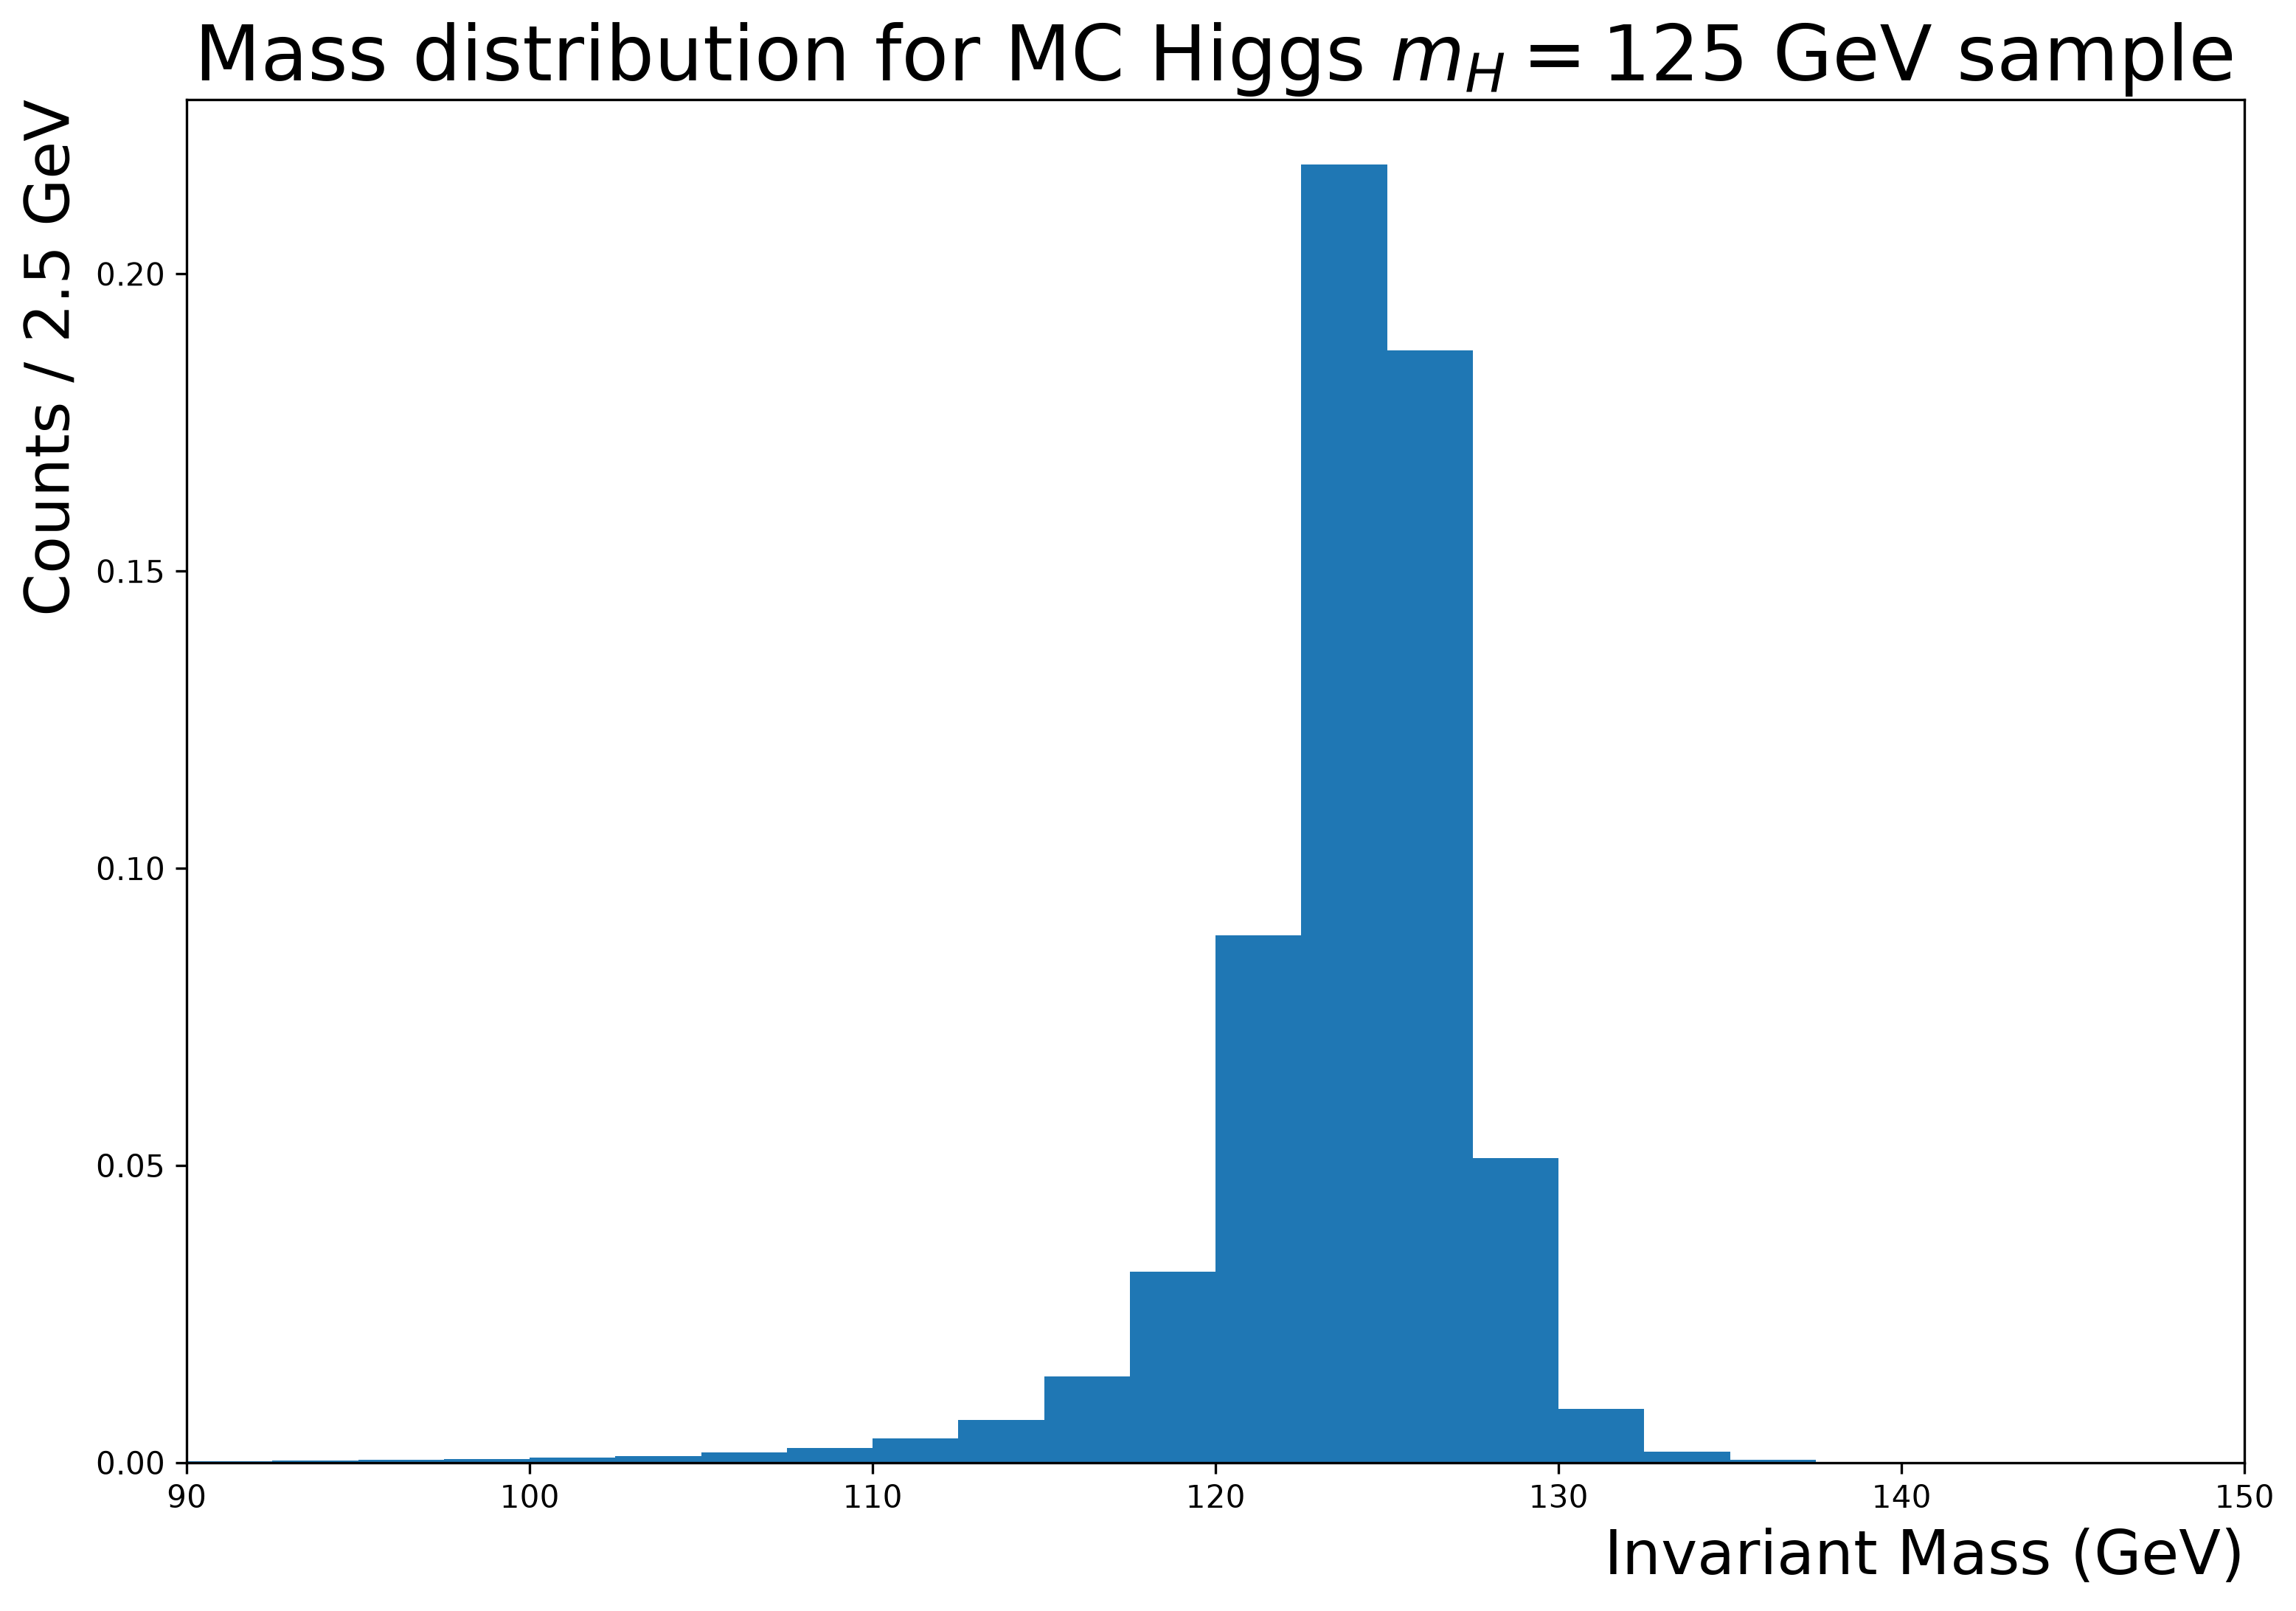

In [9]:
# now plot this MC signal process

# convert from ak to np array for plotting
mctest_masses = ak.to_numpy(mass_mctest_arr)
mctest_weights = ak.to_numpy(weights_mctest_arr)

fig, ax = plt.subplots(figsize=(12,8),dpi=300)
ax.hist(mctest_masses,bins=binlist,weights=mctest_weights)
ax.set_xlim(90,150)
ax.set_xlabel("Invariant Mass (GeV)",x=1,horizontalalignment ='right',fontsize=20)
ax.set_ylabel(f'Counts / {stepsize} GeV',y=1,horizontalalignment ='right',fontsize=20)
ax.set_title("Mass distribution for MC Higgs $m_H = 125$ GeV sample",fontsize=25)


# LOOP OVER ALL FILES

In [119]:
# loop through all files
lumi = 36.6 #fb-1, total luminosity of the release
mz = 91.2
allinfo = {} # empty dictionary for ak arrays, info includes data and MC
allz1masses = {}
allz2masses = {}

# loop over Data, MC signal, MC backgrounds
for s in allsamples:
    print("\n\n Processing sample: " + str(s))
    #check to see if it's a data or MC sample to see whether need to do mass cuts
    if s != 'Data': mcbool = True
    else: mcbool = False

    thissample_info = []
    mz1_thissample = []
    mz2_thissample = []
    # loop over all files in this sample
    for i,f in enumerate(allsamples[s]['list']):
        #if i>5:
        #    break
        starttime = time.time() # start timer
        print(r'\t Processing file: ' + str(f))

        # open the file, the tree is named analysis
        file = uproot.open(f)
        tree = file['analysis']

        chunks = []
        # loop through tree
        for data in tree.iterate(allvars,library='ak'):
            # do cuts on the data file
            print("Num events before cuts: "+str(len(data)))

            # the cuts are vectorized for effiency
            # each cut passes a bool array back to the data ak array
            # for all events with False in the bool array, the event is tossed

            data = data[cut_lep_n(data['lep_n'])]
            print("Num events after lep_n cuts: "+str(len(data)))

            data = data[cut_trigger(data['trigE'],data['trigM'])]
            data = data[cut_trigger_match(data['lep_isTrigMatched'])]
            print("Num events after trigger cuts: "+str(len(data)))

            data = data[cut_pt(data['lep_pt'])]
            print("Num events after pt cuts: "+str(len(data)))

            # electron should have loose ID, ID comes from ecal
            # muon should have medium ID (atlas recommendation?)
            # both should have loose iso criteria
            # inputs are pid,id_e,iso_e,id_mu,iso_mu
            data = data[cut_ID_iso(data['lep_type'],data['lep_isLooseID'],
                        data['lep_isLooseIso'],data['lep_isMediumID'],
                        data['lep_isLooseIso'])]
            print("Num events after ID iso cuts: "+str(len(data)))

            data = data[cut_lep_charge(data['lep_charge'])]
            print("Num events after lep charge cuts: "+str(len(data)))
            
            data = data[cut_lep_type(data['lep_type'])]
            print("Num events after lep type cuts: "+str(len(data)))

            #calculate mass
            data['mass'] = calc_mass(data['lep_pt'],data['lep_eta'],data['lep_phi'],data['lep_e'])
            #print(data['mass'])

            chunks.append(data)
            
        file_data = ak.concatenate(chunks)
        nIn = len(file_data)
        print(f"Num events after all original cuts (not Z1/Z2): {nIn}")

        #file_data = file_data[:10000]  # for fast iteration while debugging
        #print(f"Max num events capped, num events: {len(file_data)}")

        # lists for Z1/Z2 reconstruction/analysis
        pass_events = [] # will be a bool list of length n_events before Z1/Z2 cuts
        mz1list = [] # will have length n_events after Z1/Z2 cuts
        mz2list = []

        # for this file, now apply Z1/Z2 analysis by looping over events
        for event in file_data:
            lep_pt     = ak.to_numpy(event['lep_pt'])
            lep_eta    = ak.to_numpy(event['lep_eta'])
            lep_phi    = ak.to_numpy(event['lep_phi'])
            lep_E      = ak.to_numpy(event['lep_e'])
            lep_type   = ak.to_numpy(event['lep_type'])
            lep_charge = ak.to_numpy(event['lep_charge'])

            # pass all to Z analysis fxn
            passevent, mZ1, mZ2 = cut_Z1Z2(lep_pt,lep_eta,lep_phi,lep_E,lep_charge,lep_type)
            pass_events.append(passevent)

            if passevent:
                mz1list.append(mZ1)
                mz2list.append(mZ2)
        
        #cut the num events further based on Z1/Z2 cuts
        file_data = file_data[pass_events]
        print("Num events after Z1/Z2 cuts: "+str(len(file_data)))

        if mcbool == True:
            file_data['totalWeight'] = calc_weight(file_data[weight_vars],weight_vars,file_data['sum_of_weights'],lumi)
            # if MC, nOut should be sum of weights
            nOut = sum(file_data['totalWeight'])
        else:
            nOut = len(file_data)

        thissample_info.append(file_data)
        mz1_thissample.append(mz1list)
        mz2_thissample.append(mz2list)
        endtime = time.time()
        duration = endtime - starttime
        print(f"\t nIn:{nIn}\tnOut:{nOut}\tin {round(duration,1)} s.")

    allinfo[s] = ak.concatenate(thissample_info)
    allz1masses[s] = mz1_thissample
    allz2masses[s] = mz2_thissample



 Processing sample: Data
\t Processing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodD.4lep.root
Num events before cuts: 3708
Num events after lep_n cuts: 3424
Num events after trigger cuts: 395
Num events after pt cuts: 110
Num events after ID iso cuts: 2
Num events after lep charge cuts: 2
Num events after lep type cuts: 2
Num events after all original cuts (not Z1/Z2): 2
Num events after Z1/Z2 cuts: 2
	 nIn:2	nOut:2	in 0.3 s.
\t Processing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodE.4lep.root
Num events before cuts: 27501
Num events after lep_n cuts: 25092
Num events after trigger cuts: 3420
Num events after pt cuts: 765
Num events after ID iso cuts: 19
Num events after lep charge cuts: 17
Num events after lep type cuts: 17
Num events after all original cuts (not Z1/Z2): 17
Num events after Z1/Z2 cuts: 13
	 nIn:17	nOut:13	in 1.1 s.
\t Processing f

# Plot of all Data + MC (with ZZ* cuts)

Num of data events that pass cut: 1078


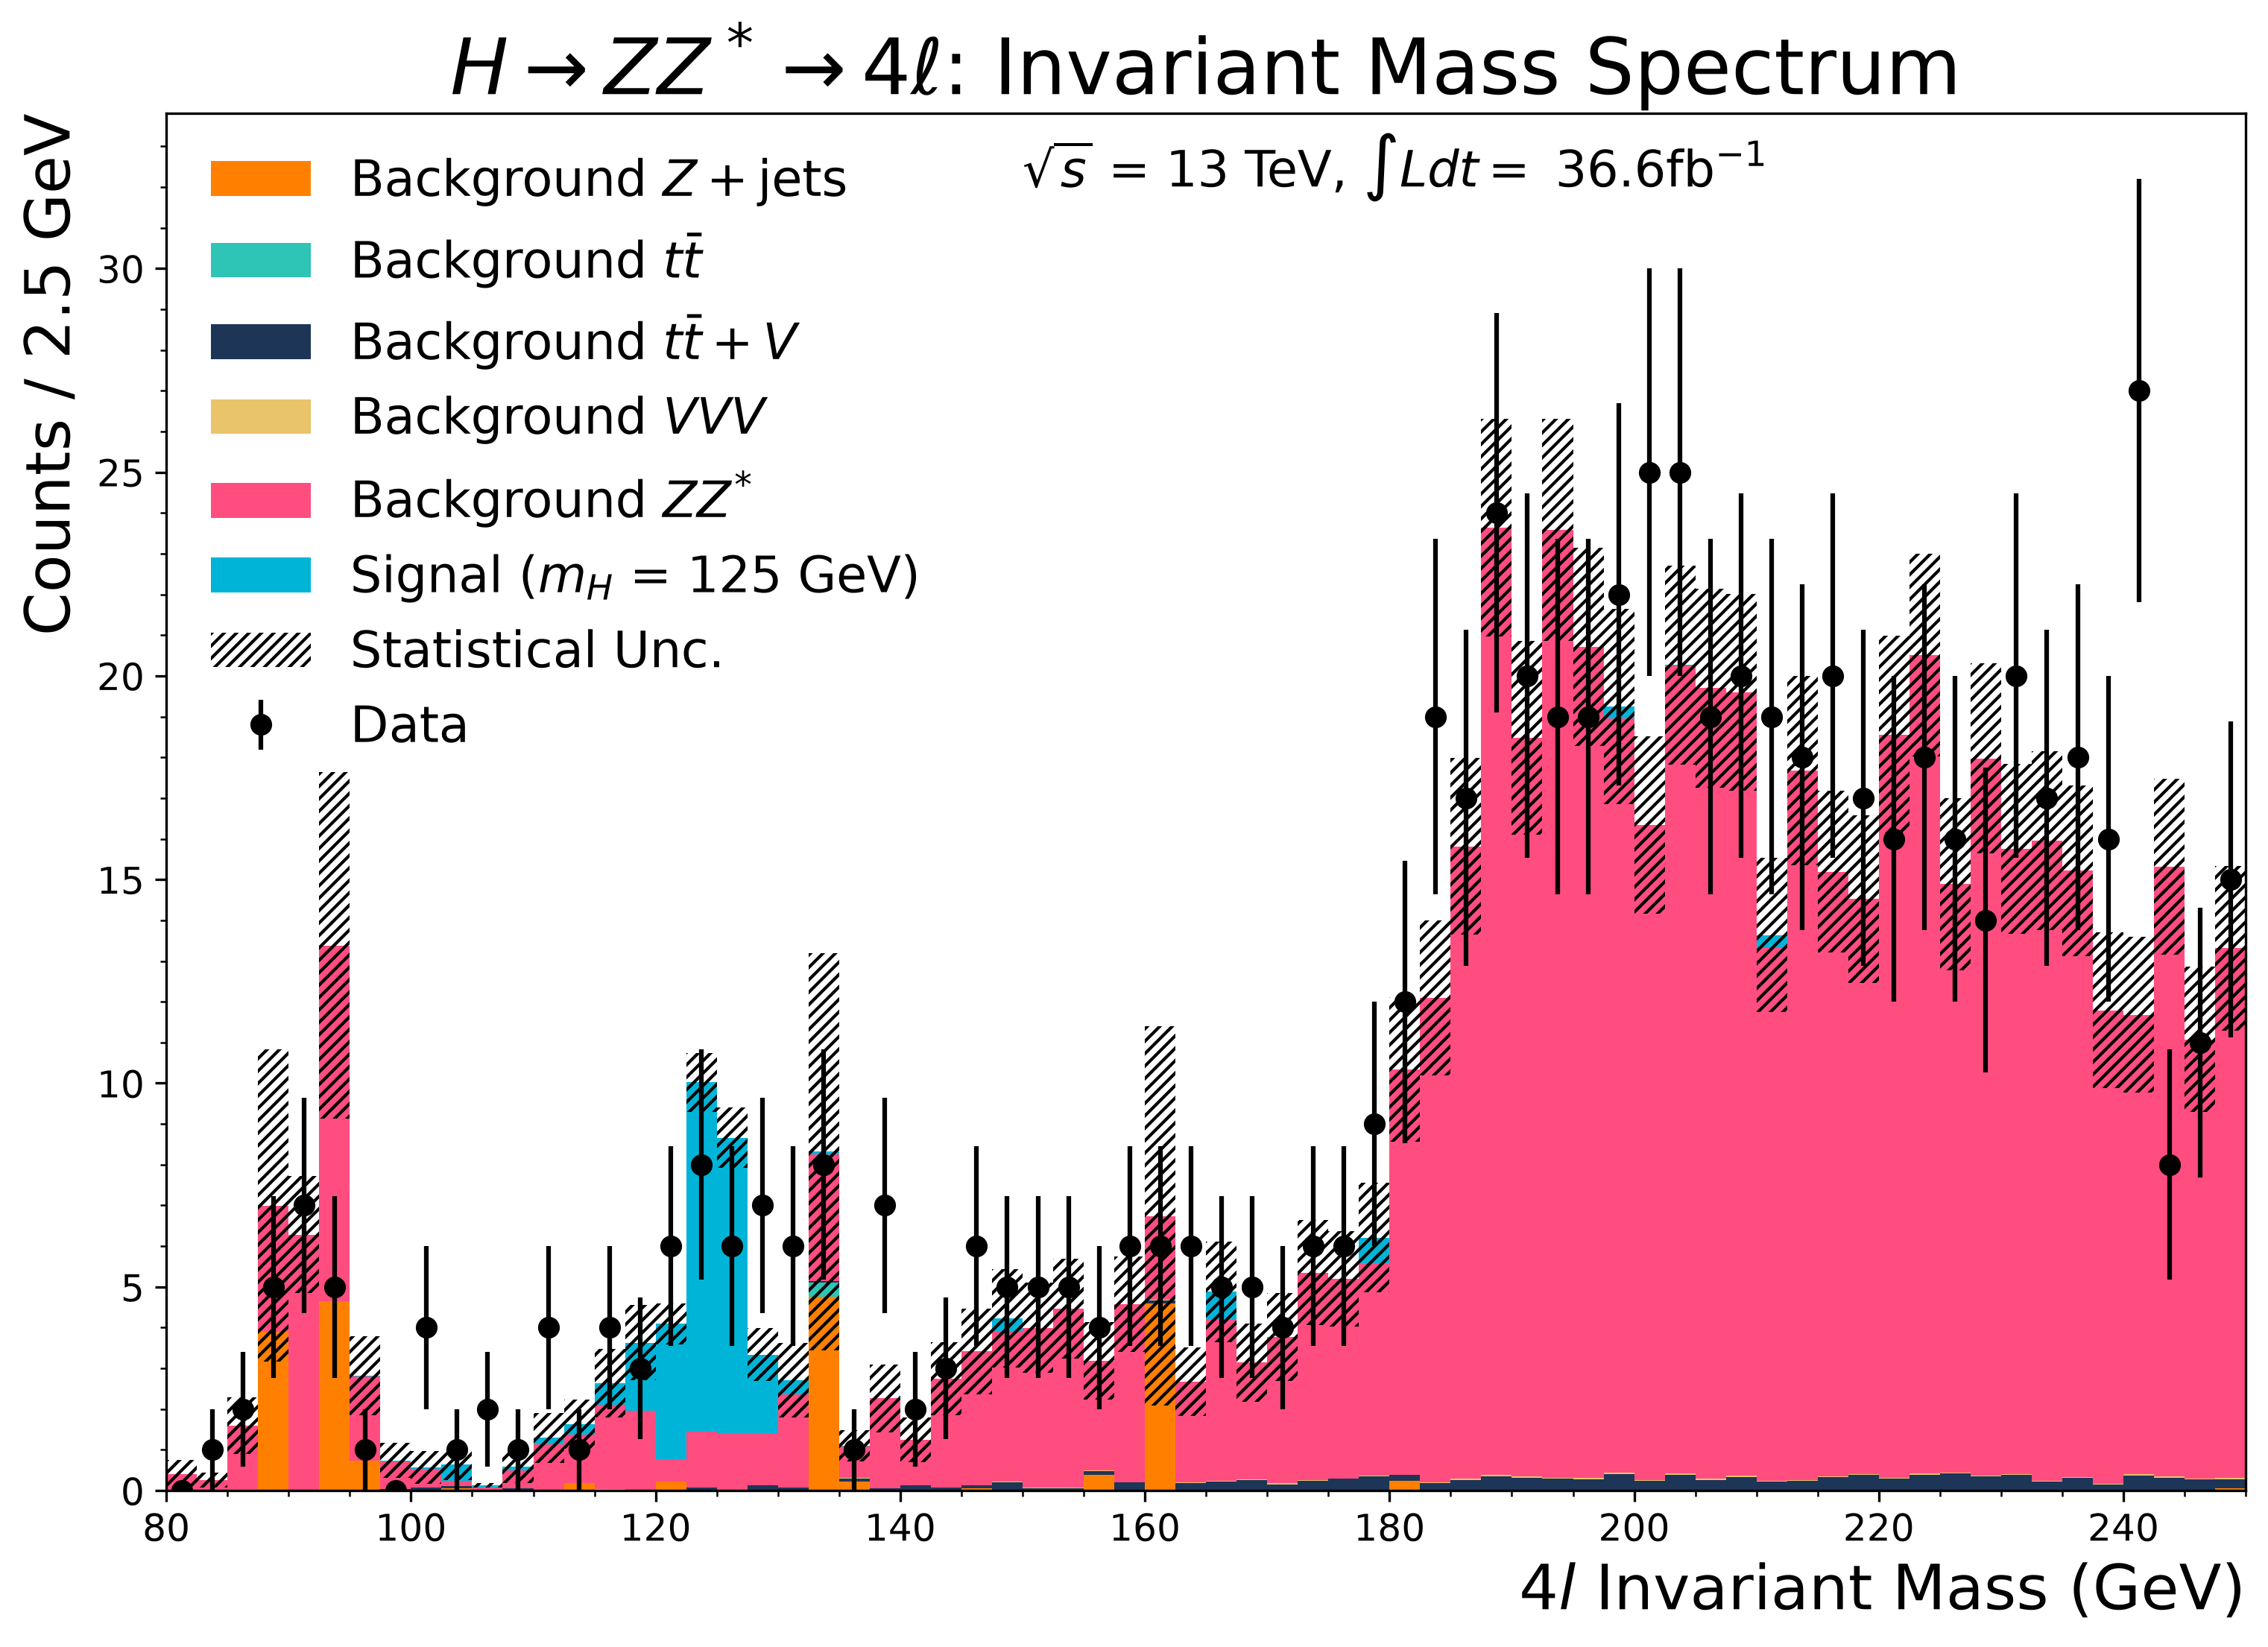

In [170]:
### Plot with Z1/Z2 cut implemented

# data:
data_x = ak.to_numpy(allinfo['Data']['mass'])
print(f'Num of data events that pass cut: {len(data_x)}')
data_y,_ = np.histogram(data_x,bins=binlist)
data_y_err = np.sqrt(data_y) # statistical error use poisson uncertainty

# don't need to histogram the MC data because we are plotting them as hist, use plt.hist

fig, ax = plt.subplots(figsize=(12,8),dpi=300)
# make lists for the different MC samples for each of the attributes needed for plotting
mc_masses = [] # each entry will be a list of the masses for that MC sample
mc_weights = []
mc_labels = []
#TODO - rescue these colors
#mc_colors = ['#6CBAA9','#E4A199','#E8A87C'] # pastel
#mc_colors = ['#4A274E','#E4A199','#D3C5E5']
mc_colors = ['#A8DADC', '#457B9D', '#1D3557'] # blue pastel
mc_colors = ['#E9C46A', '#F4A261', '#E76F51']
mc_colors = ["#FF8000", '#2EC4B6', '#118AB2']
mc_colors = ["#F8B200", '#FF4D80', '#023047']
mc_colors = ['#F15BB5', '#E76F51', '#2A9D8F']
mc_colors = ['#D8E2DC', '#FFE5D9', '#D2B7E5', '#9DB4C0', '#F4A261', '#0077B6']
mc_colors = ['#FF8000', '#2EC4B6', '#1D3557', '#E9C46A', '#FF4D80', '#00B4D8']
for s in allsamples:
    if s != 'Data': # just MC samples
        # make numpy lists of the mass+weights
        thismc_mass = ak.to_numpy(allinfo[s]['mass'])
        mc_masses.append(thismc_mass)
        thismc_weights = ak.to_numpy(allinfo[s]['totalWeight'])
        mc_weights.append(thismc_weights)
        #mc_colors.append(allsamples[s]['color'])
        mc_labels.append(s)

mc_hist = ax.hist(mc_masses,bins=binlist,weights=mc_weights,
        label=mc_labels,color=mc_colors,stacked=True)

# this mc_hist object is a tuple, first entry is a 2D array for the height of the hist
# the first entry is the heights of bins for first sample
# if stacked=True, second entry is heights of first + second
# third entry is height of first+second+third, etc.
# so take the last row of the first element of the mc_hist tuple to get cumulative height
mc_height_sum = mc_hist[0][-1]


# now make error bars for the MC samples
# in the tutorial files they only do error bars for the MC BG, i include signal
# concatenate all mc weights and mass into long list
mc_weights_all = np.concatenate(mc_weights)
mc_masses_all = np.concatenate(mc_masses)
# the total variance per bin is the weight^2
# so histogram the masses with weight^2
mc_var_hist = np.histogram(mc_masses_all,bins=binlist, weights=mc_weights_all**2)
# np hist returns tuple, first element is bin height
mc_err = np.sqrt(mc_var_hist[0])

# plot mc errorbars
# calc the bottom of the bar with the height of the total mc
ax.bar(bincenters,height=mc_err*2,bottom=(mc_height_sum-mc_err),
       hatch='//////',color='none',alpha=0.5,width=stepsize,label="Statistical Unc.")


#TODO - find better text for labeling plot
ax.errorbar(bincenters,data_y,yerr=data_y_err,fmt='o',color='black',label='Data') 

#TODO - explain plot, think about discrepencies between data and MC bg predictions
#TODO - also think about the luminosity

ax.set_xlabel(r"$4l$ Invariant Mass (GeV)",x=1,horizontalalignment ='right',fontsize=20)
ax.set_ylabel(f'Counts / {stepsize} GeV',y=1,horizontalalignment ='right',fontsize=20)
ax.set_title(r"$H \rightarrow ZZ^* \rightarrow 4\ell$: Invariant Mass Spectrum",fontsize=25)
ax.legend(frameon=False,fontsize=16)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(80,250)
plt.text(150,32,r'$\sqrt{s}$ = 13 TeV, $\int L dt =$ 36.6fb$^{-1}$',fontsize=16)
plt.savefig("plots/massspec_final.png")

# Notes about plot

#TODO - understand the physics of the soft Z
#TODO - fi

1) The 90 GeV peak dissapears when I added the $ZZ^*$ cut. This shows that the cut is working as it's supposed to - the peak is caused by events with one on-shell Z and one off shell Z with low mass - caused by a very soft SFOS pair. This low energy $Z^*$ can be caused by "virtual photon internal conversion, final-state radiation, or a soft non-resonant pair"
2) The 240 GeV data point is likely a statistical fluctation. MC predicts roughly 15 events per bin at this energy, data shows 27. With Poisson uncertainty, $(27-15)/\sqrt{15} \approx 3 \sigma$. With ~70 bins, we'd expect $70*0.01=0.7$ bins to have a 3 $\sigma$ fluctuation. Also because it shows up before and after the Z1/Z2 cut, it's stronger evidence of statistical fluctuation.
3) Discrepency around 90GeV peak. Because the statistics are low, the discrepency is likely result of large uncertainties.
4) The ATLAS open data MC samples use a simplified weighting scheme. In the real analysis, the backgrounds are estimated with data-driven techniques instead of pure MC prediction because MC modeling of jets faking leptons is unreliable. #TODO - find source for this.

# Z1 / Z2 reconstruction plots

(45.0, 110.0)

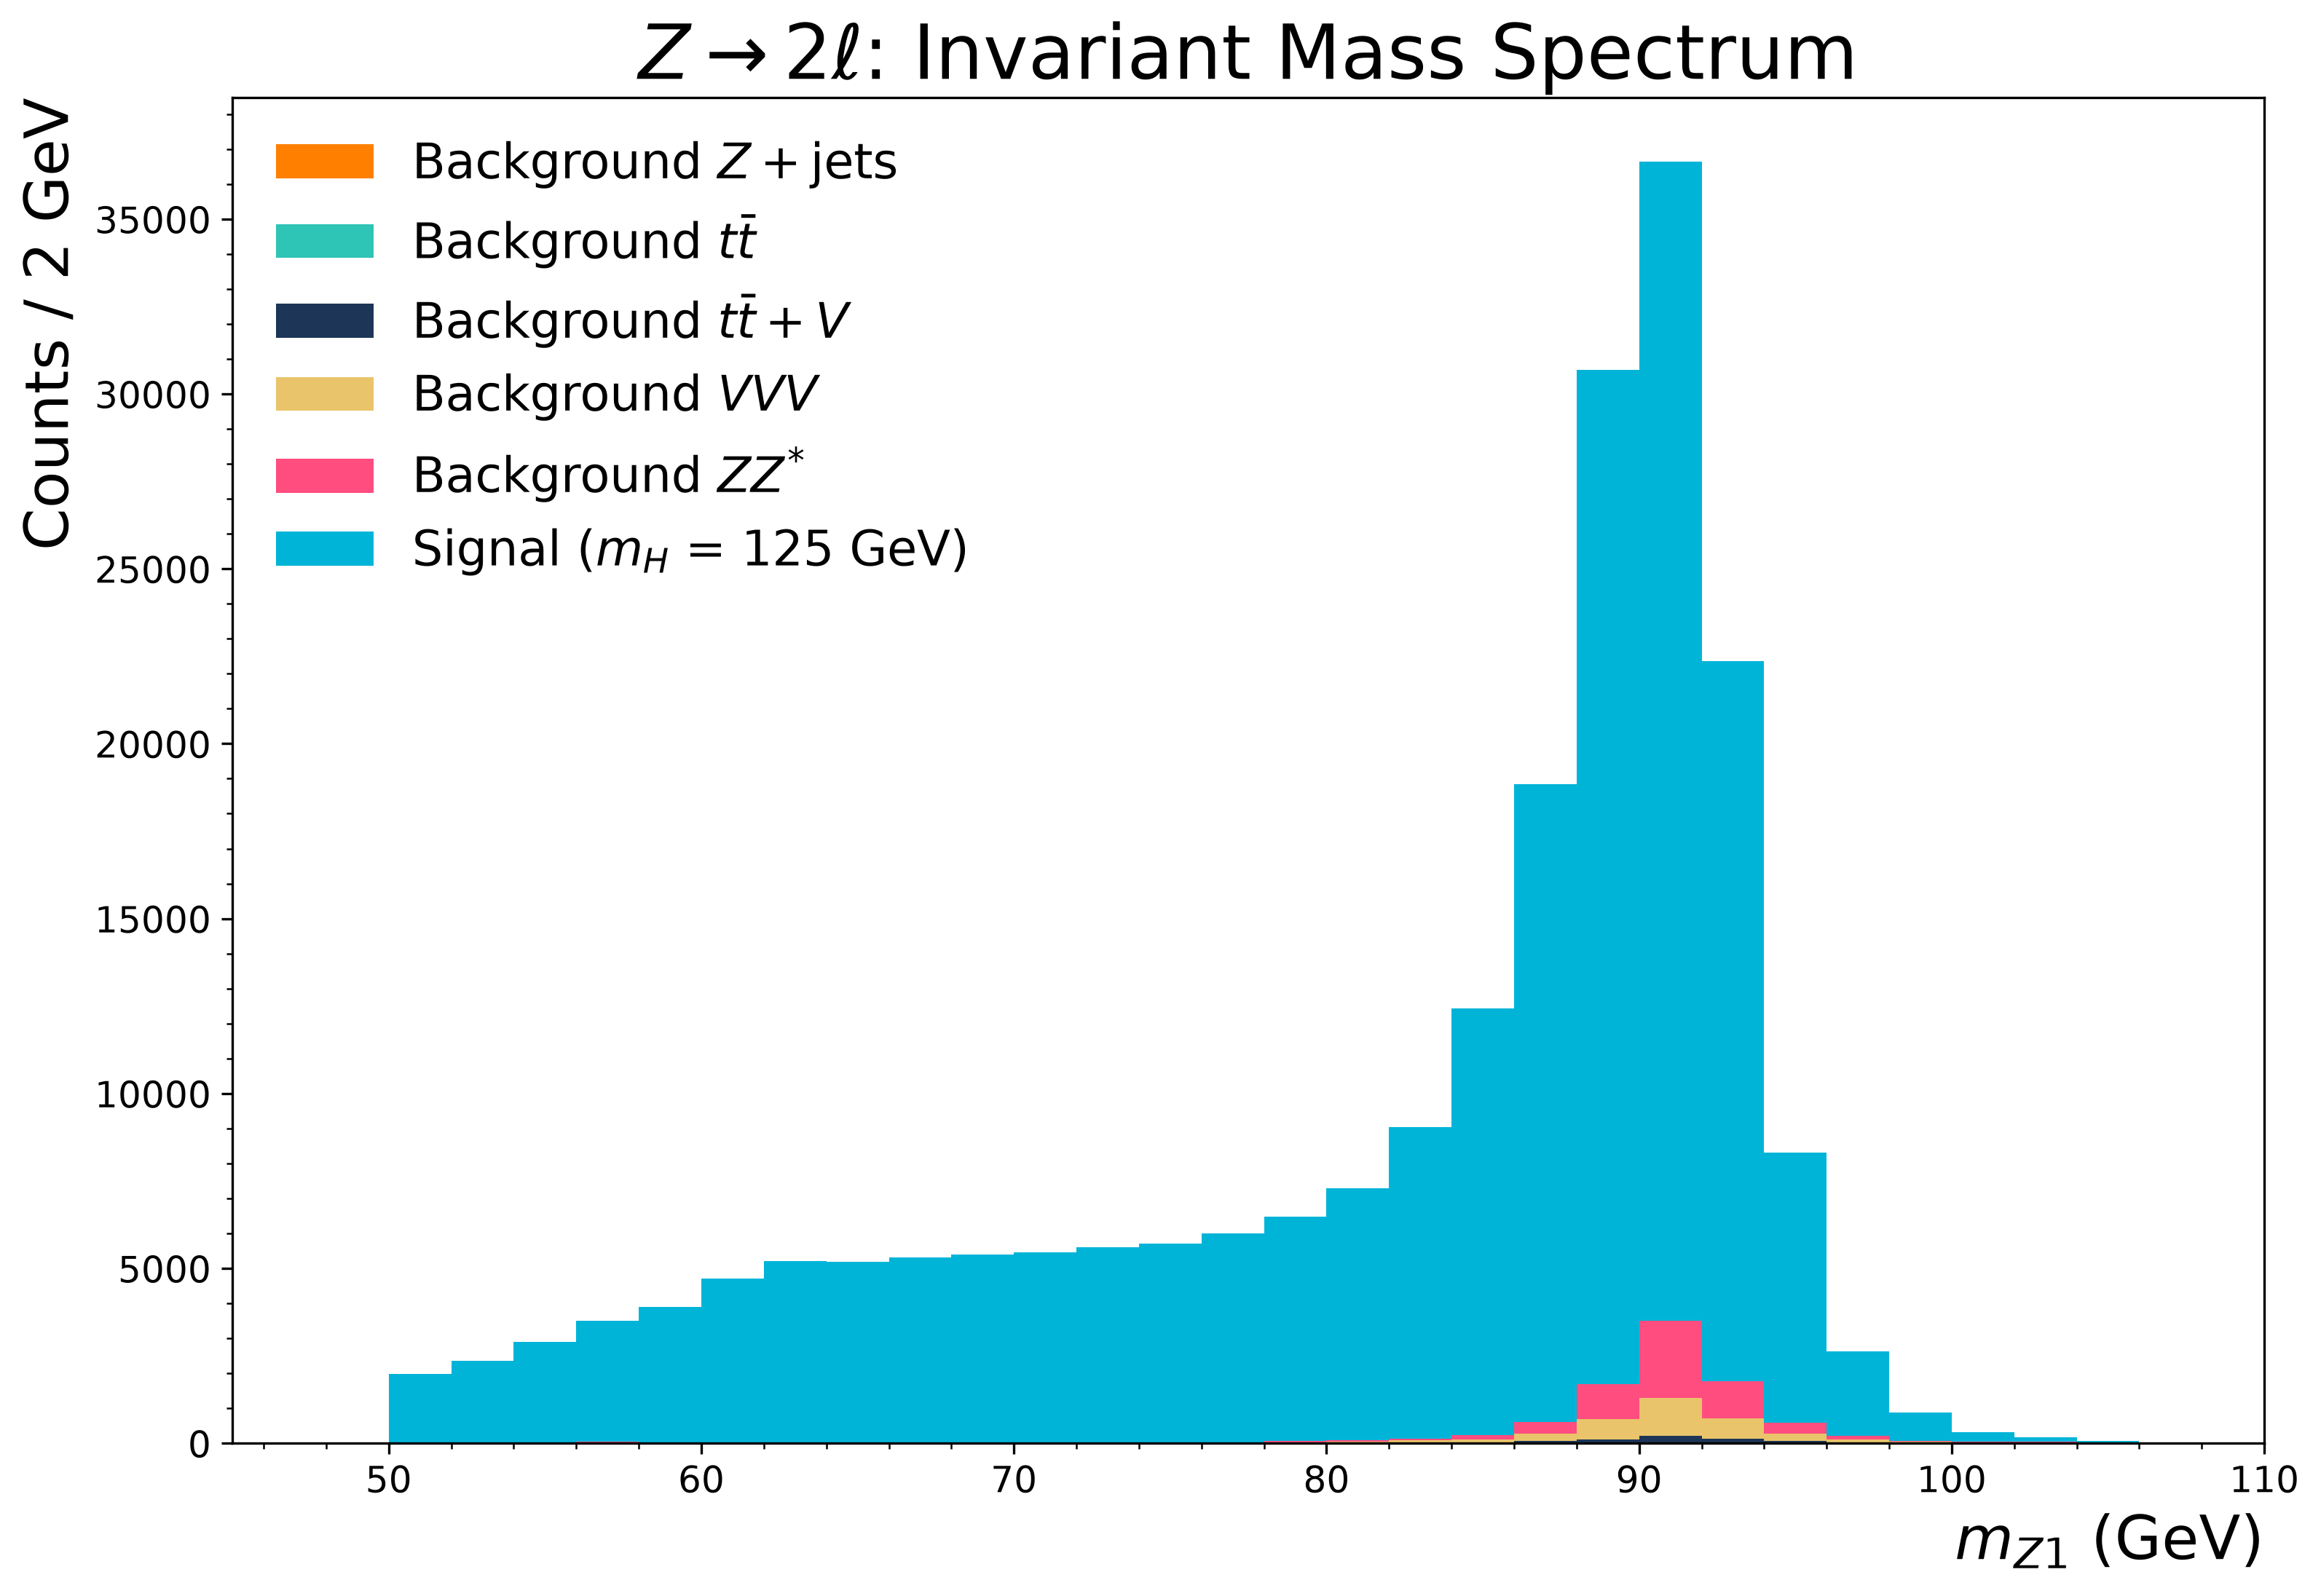

In [158]:
# new plot defs
xmin_zs = 0 # GeV for all 
xmax_zs = 450
stepsize_zs = 2 
binlist_zs = np.arange(xmin_zs,xmax_zs+stepsize_zs,stepsize_zs)
bincenters_zs = np.arange(xmin_zs+stepsize_zs/2,xmax_zs+stepsize_zs/2,stepsize_zs)

# data:

# concat all z1 mass data, original awkward array has one entry per sample
data_x_z1 = ak.to_numpy(ak.concatenate(allz1masses['Data']))
data_x_z2 = ak.to_numpy(ak.concatenate(allz2masses['Data']))

data_y_z1,_ = np.histogram(data_x_z1,bins=binlist_zs)
data_y_z2,_ = np.histogram(data_x_z2,bins=binlist_zs)
data_y_err_z1 = np.sqrt(data_y_z1) # statistical error use poisson uncertainty
data_y_err_z2 = np.sqrt(data_y_z2) # statistical error use poisson uncertainty

fig, ax = plt.subplots(figsize=(12,8),dpi=300)
# make lists for the different MC samples for each of the attributes needed for plotting
mc_masses_z1 = [] # each entry will be a list of the masses for that MC sample
mc_masses_z2 = []
mc_labels = []

mc_colors = ['#FF8000', '#2EC4B6', '#1D3557', '#E9C46A', '#FF4D80', '#00B4D8']

for s in allsamples:
    if s != 'Data': # just MC samples
        # make numpy lists of the mass+weights
        thismc_mass_z1 = ak.to_numpy(ak.concatenate(allz1masses[s]))
        mc_masses_z1.append(thismc_mass_z1)
        thismc_mass_z2 = ak.to_numpy(ak.concatenate(allz2masses[s]))
        mc_masses_z2.append(thismc_mass_z2)
        mc_labels.append(s)

mc_hist_z1 = ax.hist(mc_masses_z1,bins=binlist_zs,
        label=mc_labels,color=mc_colors,stacked=True)

# this mc_hist object is a tuple, first entry is a 2D array for the height of the hist
# the first entry is the heights of bins for first sample
# if stacked=True, second entry is heights of first + second
# third entry is height of first+second+third, etc.
# so take the last row of the first element of the mc_hist tuple to get cumulative height
# mc_height_sum = mc_hist_z1[0][-1]


# # now make error bars for the MC samples
# # in the tutorial files they only do error bars for the MC BG, i include signal
# # concatenate all mc weights and mass into long list
# mc_weights_all = np.concatenate(mc_weights)
# mc_masses_all = np.concatenate(mc_masses)
# # the total variance per bin is the weight^2
# # so histogram the masses with weight^2
# mc_var_hist = np.histogram(mc_masses_all,bins=binlist, weights=mc_weights_all**2)
# # np hist returns tuple, first element is bin height
# mc_err = np.sqrt(mc_var_hist[0])

# # plot mc errorbars
# # calc the bottom of the bar with the height of the total mc
# ax.bar(bincenters,height=mc_err*2,bottom=(mc_height_sum-mc_err),
#        hatch='//////',color='none',alpha=0.5,width=stepsize,label="Statistical Unc.")


#ax.errorbar(bincenters_zs,data_y,yerr=data_y_err,fmt='o',color='black',label='Data') 

#TODO - also think about the luminosity

ax.set_xlabel(r"$m_{Z1}$ (GeV)",x=1,horizontalalignment ='right',fontsize=20)
ax.set_ylabel(f'Counts / {stepsize_zs} GeV',y=1,horizontalalignment ='right',fontsize=20)
ax.set_title(r"$Z \rightarrow 2\ell$: Invariant Mass Spectrum",fontsize=25)
ax.legend(frameon=False,fontsize=16)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(45,110)
#plt.text(150,32,r'$\sqrt{s}$ = 13 TeV, $\int L dt =$ 36.6fb$^{-1}$',fontsize=16)

(0.0, 120.0)

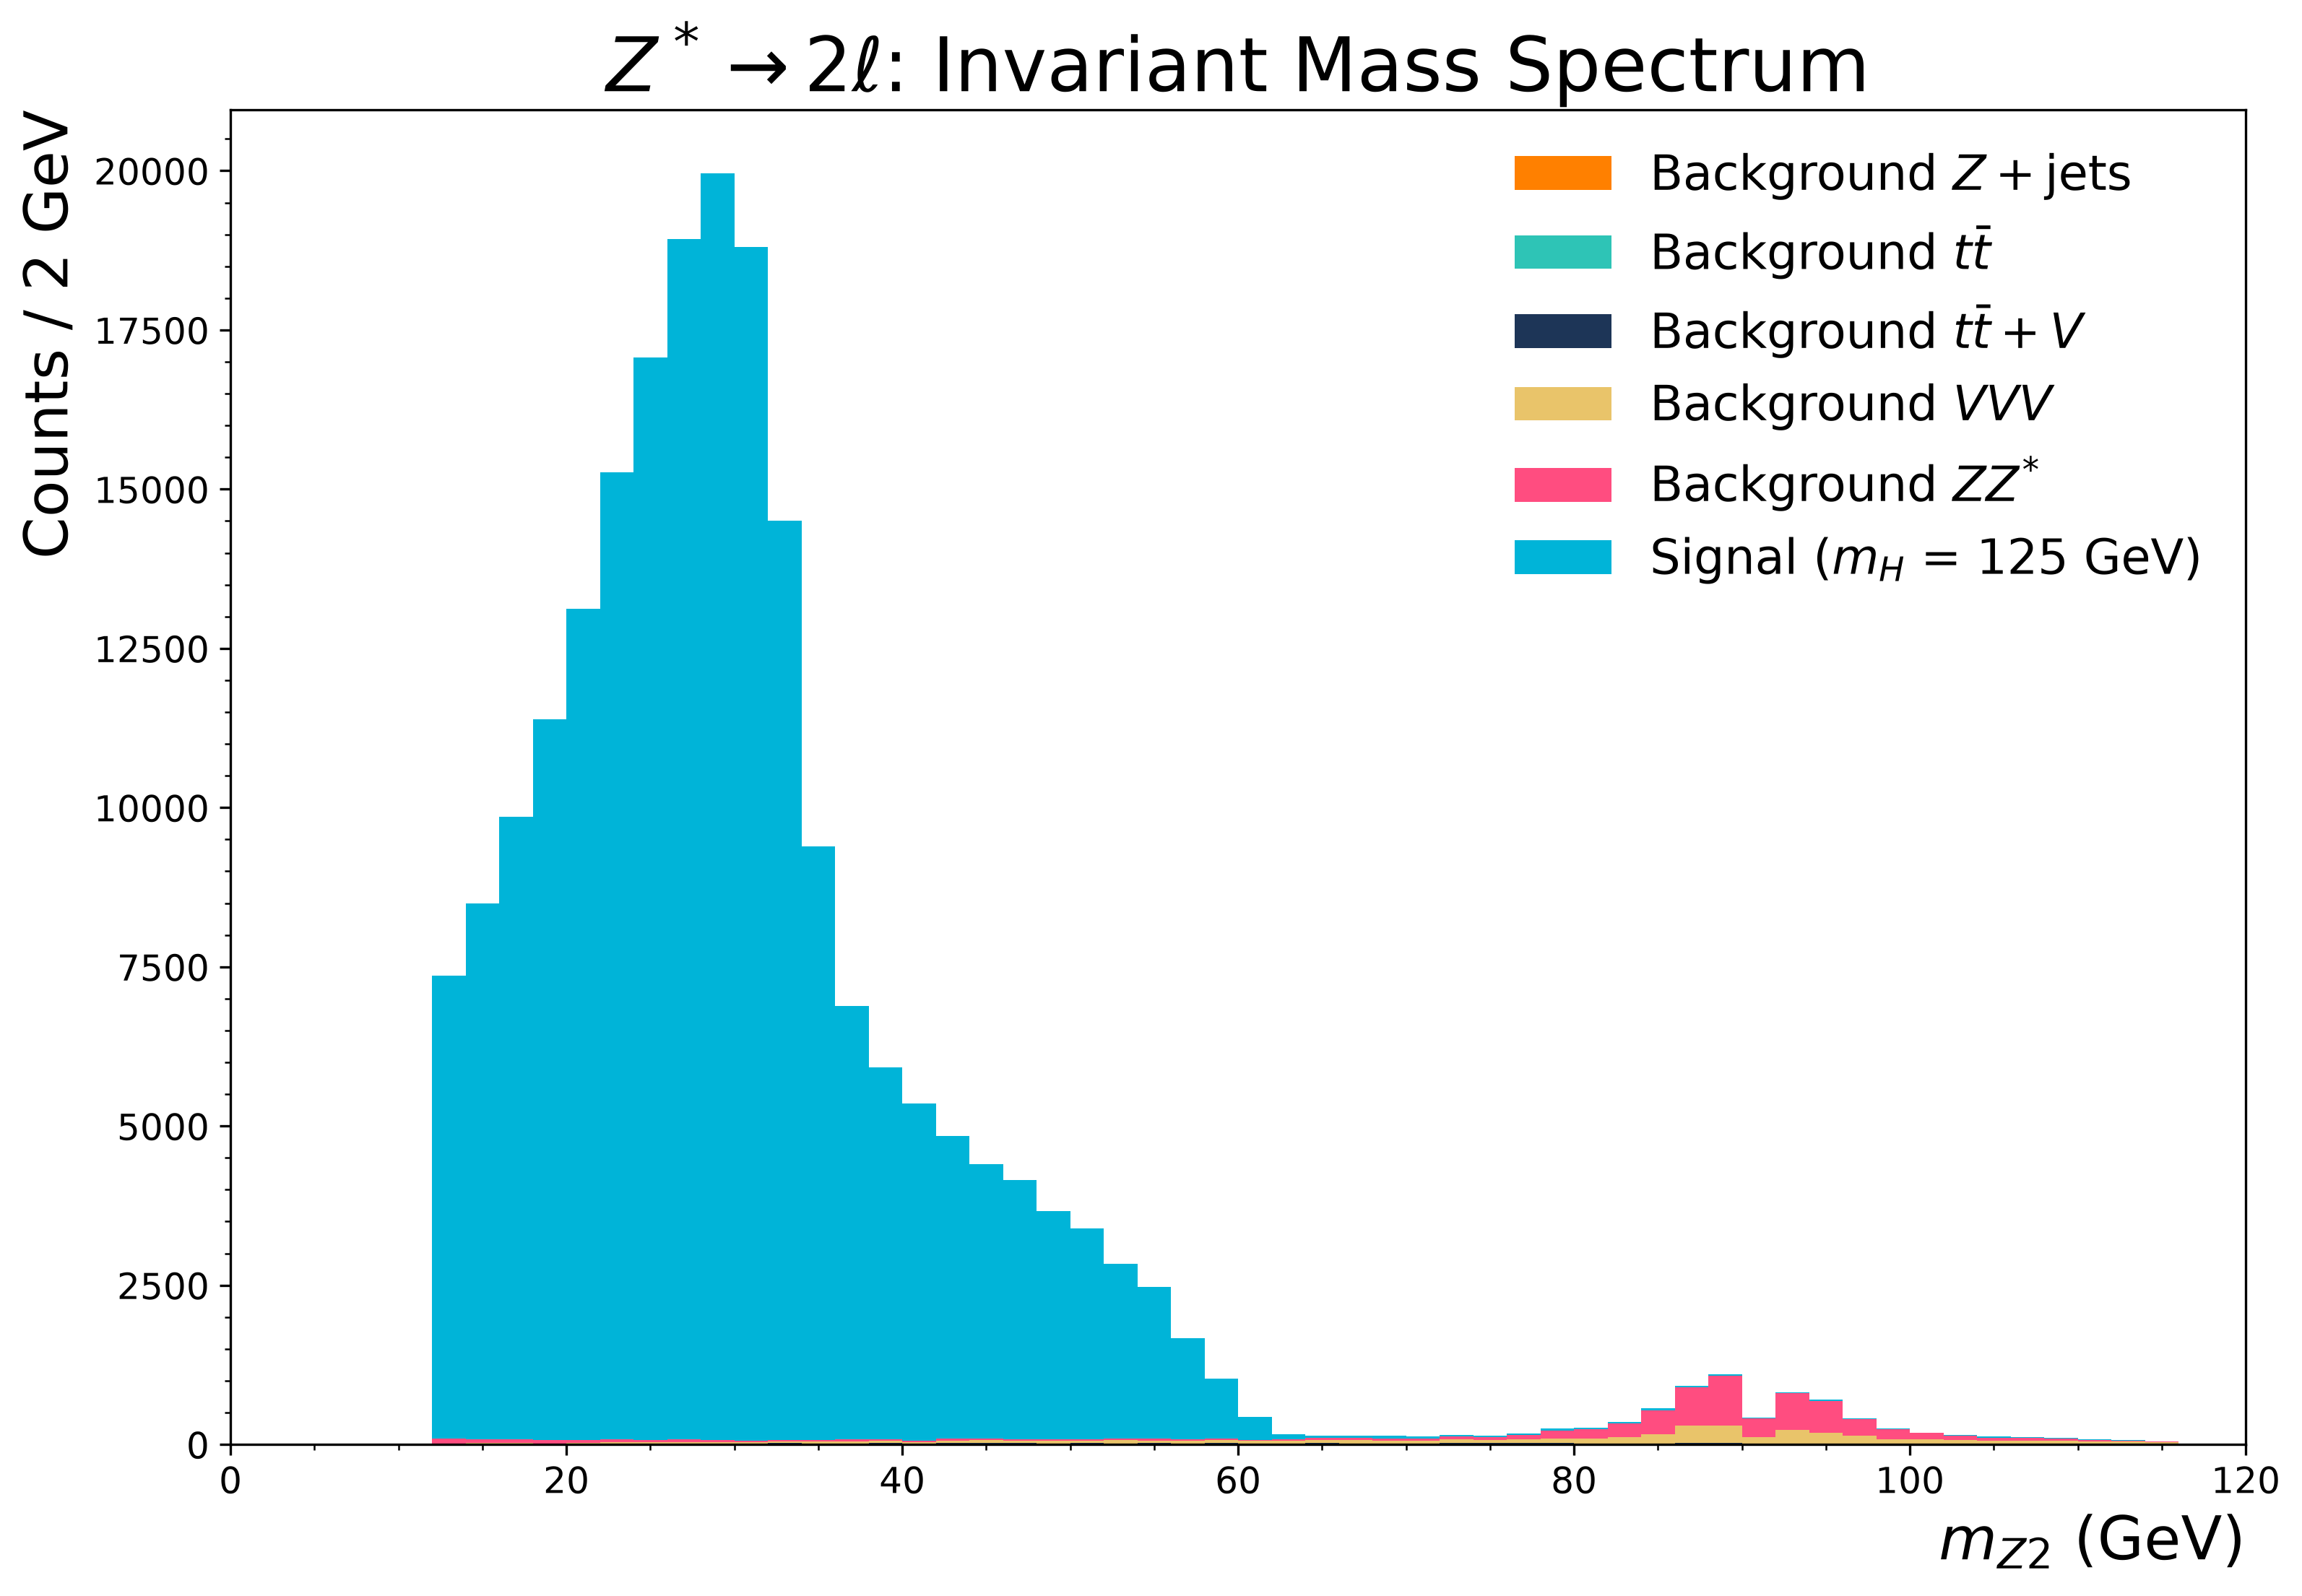

In [160]:
ig, ax = plt.subplots(figsize=(12,8),dpi=300)
mc_hist_z2 = ax.hist(mc_masses_z2,bins=binlist_zs,
        label=mc_labels,color=mc_colors,stacked=True)

# this mc_hist object is a tuple, first entry is a 2D array for the height of the hist
# the first entry is the heights of bins for first sample
# if stacked=True, second entry is heights of first + second
# third entry is height of first+second+third, etc.
# so take the last row of the first element of the mc_hist tuple to get cumulative height
# mc_height_sum = mc_hist_z1[0][-1]


# # now make error bars for the MC samples
# # in the tutorial files they only do error bars for the MC BG, i include signal
# # concatenate all mc weights and mass into long list
# mc_weights_all = np.concatenate(mc_weights)
# mc_masses_all = np.concatenate(mc_masses)
# # the total variance per bin is the weight^2
# # so histogram the masses with weight^2
# mc_var_hist = np.histogram(mc_masses_all,bins=binlist, weights=mc_weights_all**2)
# # np hist returns tuple, first element is bin height
# mc_err = np.sqrt(mc_var_hist[0])

# # plot mc errorbars
# # calc the bottom of the bar with the height of the total mc
# ax.bar(bincenters,height=mc_err*2,bottom=(mc_height_sum-mc_err),
#        hatch='//////',color='none',alpha=0.5,width=stepsize,label="Statistical Unc.")


#ax.errorbar(bincenters_zs,data_y,yerr=data_y_err,fmt='o',color='black',label='Data') 

#TODO - also think about the luminosity

ax.set_xlabel(r"$m_{Z2}$ (GeV)",x=1,horizontalalignment ='right',fontsize=20)
ax.set_ylabel(f'Counts / {stepsize_zs} GeV',y=1,horizontalalignment ='right',fontsize=20)
ax.set_title(r"$Z^* \rightarrow 2\ell$: Invariant Mass Spectrum",fontsize=25)
ax.legend(frameon=False,fontsize=16)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim(0,120)
#plt.text(150,32,r'$\sqrt{s}$ = 13 TeV, $\int L dt =$ 36.6fb$^{-1}$',fontsize=16)

In [140]:
# Make plots -> start with just data
#print(allinfo['Data'])
#
#data_x = ak.to_numpy(allinfo['Data']['mass'])
#print(f'Num of data events that pass cut: {len(data_x)}')
#data_y,_ = np.histogram(data_x,bins=binlist)
#data_y_err = np.sqrt(data_y) # statistical error use poisson uncertainty
#
#print(len(bincenters),len(data_y))
#
#fig, ax = plt.subplots(figsize=(12,8),dpi=300)
#ax.errorbar(bincenters,data_y,yerr=data_y_err,fmt='o')
#
#ax.set_xlabel("Invariant Mass (GeV)",x=1,horizontalalignment ='right',fontsize=20)
#ax.set_ylabel(f'Counts / {stepsize} GeV',y=1,horizontalalignment ='right',fontsize=20)
#ax.set_title("Mass distribution for all data samples",fontsize=25)



### Event loop + plot before Z1/Z2 cut implementation

In [127]:
# loop through all files
lumi = 36.6 #fb-1, total luminosity of the release
allinfo_nozcut = {} # empty dictionary for ak arrays, info includes data and MC

# loop over Data, MC signal, MC backgrounds
for s in allsamples:
    print("\n\n Processing sample: " + str(s))
    #check to see if it's a data or MC sample to see whether need to do mass cuts
    if s != 'Data': mcbool = True
    else: mcbool = False

    thissample_info = []
    # loop over all files in this sample
    for i,f in enumerate(allsamples[s]['list']):
        #if i>5:
        #    break
        thisfile_info = []
        starttime = time.time() # start timer
        print(r'\t Processing file: ' + str(f))

        # open the file, the tree is named analysis
        file = uproot.open(f)
        tree = file['analysis']
        # loop through tree
        for data in tree.iterate(allvars,library='ak'):
            nIn = len(data)
            # do cuts on the data file
            print("Num events before cuts: "+str(len(data)))

            # the cuts are vectorized for effiency
            # each cut passes a bool array back to the data ak array
            # for all events with False in the bool array, the event is tossed

            data = data[cut_lep_n(data['lep_n'])]
            print("Num events after lep_n cuts: "+str(len(data)))

            data = data[cut_trigger(data['trigE'],data['trigM'])]
            data = data[cut_trigger_match(data['lep_isTrigMatched'])]
            print("Num events after trigger cuts: "+str(len(data)))

            data = data[cut_pt(data['lep_pt'])]
            print("Num events after pt cuts: "+str(len(data)))

            # electron should have loose ID, ID comes from ecal
            # muon should have medium ID (atlas recommendation?)
            # both should have loose iso criteria
            # inputs are pid,id_e,iso_e,id_mu,iso_mu
            data = data[cut_ID_iso(data['lep_type'],data['lep_isLooseID'],
                        data['lep_isLooseIso'],data['lep_isMediumID'],
                        data['lep_isLooseIso'])]
            print("Num events after ID iso cuts: "+str(len(data)))

            data = data[cut_lep_charge(data['lep_charge'])]
            print("Num events after lep charge cuts: "+str(len(data)))
            
            data = data[cut_lep_type(data['lep_type'])]
            print("Num events after lep type cuts: "+str(len(data)))

            #calculate mass
            data['mass'] = calc_mass(data['lep_pt'],data['lep_eta'],data['lep_phi'],data['lep_e'])
            #print(data['mass'])

            #now do weight calculations if sample is MC
            if mcbool == True:
                data['totalWeight'] = calc_weight(data[weight_vars],weight_vars,data['sum_of_weights'],lumi)
                # if MC, nOut should be sum of weights
                nOut = sum(data['totalWeight'])
            else:
                nOut = len(data)
            
            thisfile_info.append(data)

        thissample_info.append(ak.concatenate(thisfile_info))
        endtime = time.time()
        duration = endtime - starttime
        print(f"\t nIn:{nIn}\tnOut:{nOut}\tin {round(duration,1)} s.")

    allinfo_nozcut[s] = ak.concatenate(thissample_info)



 Processing sample: Data
\t Processing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodD.4lep.root
Num events before cuts: 3708
Num events after lep_n cuts: 3424
Num events after trigger cuts: 395
Num events after pt cuts: 110
Num events after ID iso cuts: 2
Num events after lep charge cuts: 2
Num events after lep type cuts: 2
	 nIn:3708	nOut:2	in 0.3 s.
\t Processing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodE.4lep.root
Num events before cuts: 27501
Num events after lep_n cuts: 25092
Num events after trigger cuts: 3420
Num events after pt cuts: 765
Num events after ID iso cuts: 19
Num events after lep charge cuts: 17
Num events after lep type cuts: 17
	 nIn:27501	nOut:17	in 0.8 s.
\t Processing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodF.4lep.root
Num events before cuts: 17783
Num e

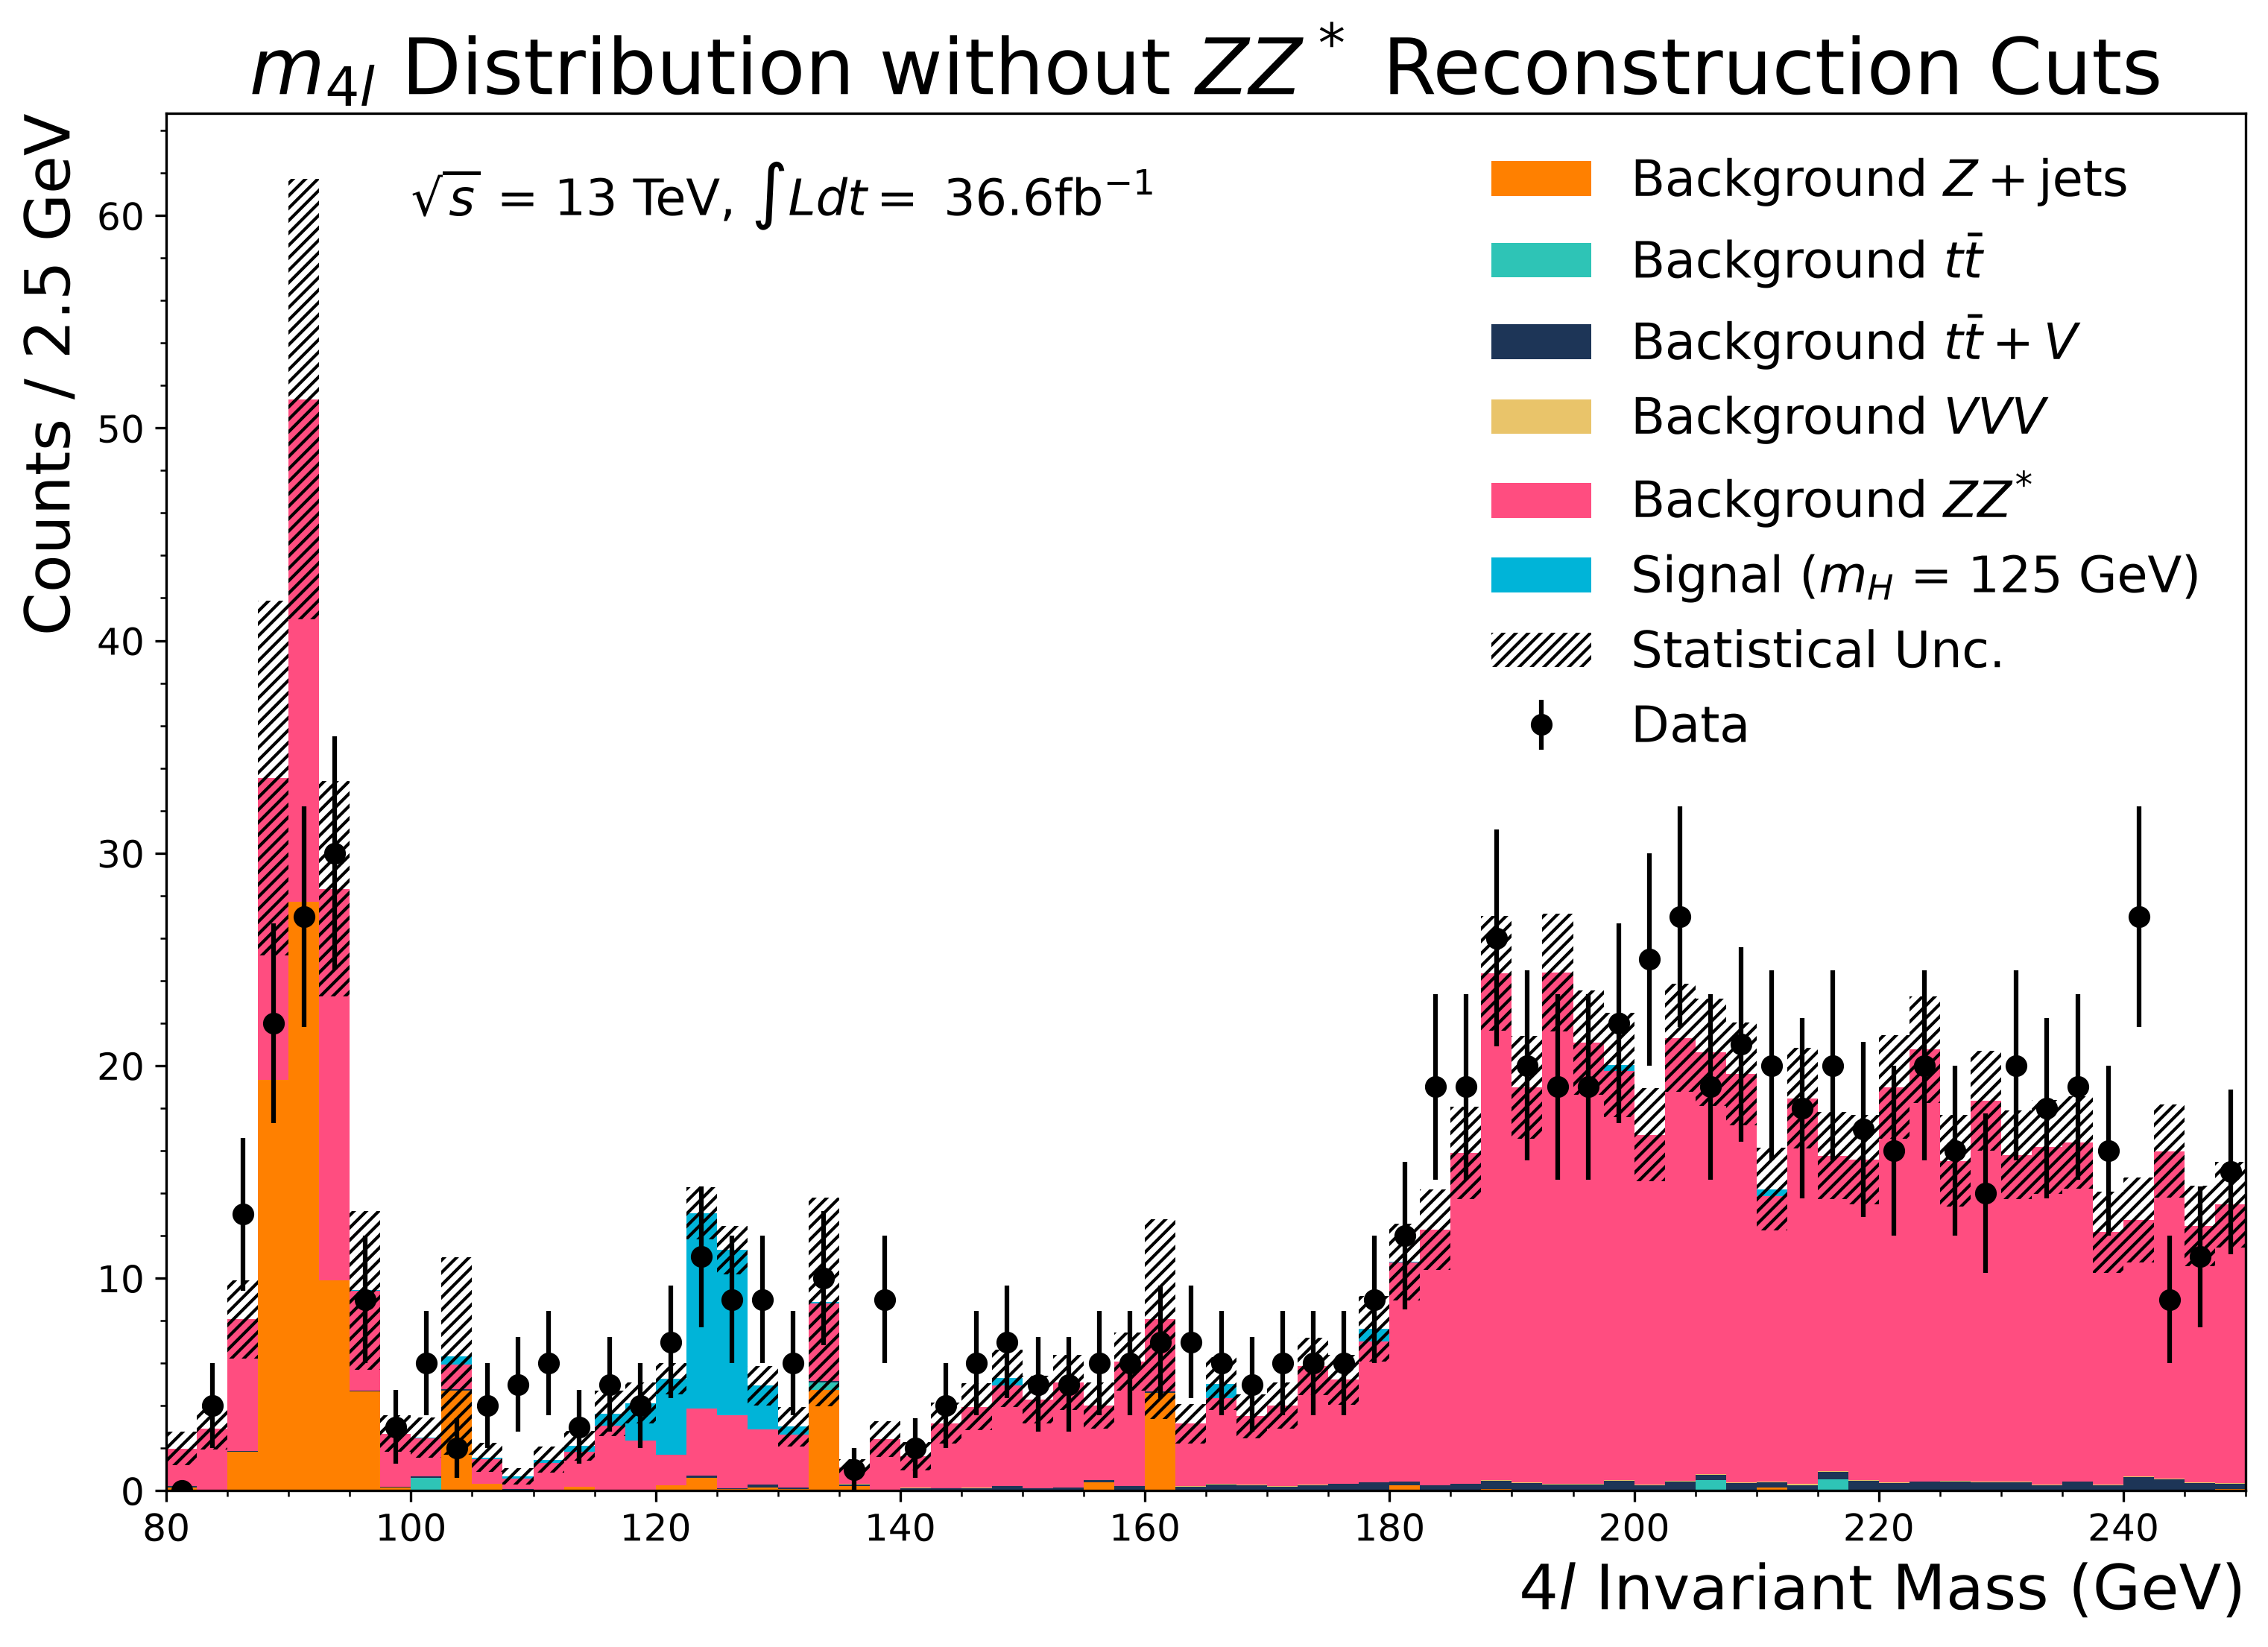

In [169]:
# Plot before Z mass window cuts

# data plots
data_x = ak.to_numpy(allinfo_nozcut['Data']['mass'])
data_y,_ = np.histogram(data_x,bins=binlist)
data_y_err = np.sqrt(data_y) # statistical error use poisson uncertainty

fig, ax = plt.subplots(figsize=(12,8),dpi=300)
# make lists for the different MC samples for each of the attributes needed for plotting
mc_masses = [] # each entry will be a list of the masses for that MC sample
mc_weights = []
mc_labels = []
#TODO - rescue these colors
#mc_colors = ['#6CBAA9','#E4A199','#E8A87C'] # pastel
#mc_colors = ['#4A274E','#E4A199','#D3C5E5']
mc_colors = ['#A8DADC', '#457B9D', '#1D3557'] # blue pastel
mc_colors = ['#E9C46A', '#F4A261', '#E76F51']
mc_colors = ["#FF8000", '#2EC4B6', '#118AB2']
mc_colors = ["#F8B200", '#FF4D80', '#023047']
mc_colors = ['#F15BB5', '#E76F51', '#2A9D8F']
mc_colors = ['#D8E2DC', '#FFE5D9', '#D2B7E5', '#9DB4C0', '#F4A261', '#0077B6']
mc_colors = ['#FF8000', '#2EC4B6', '#1D3557', '#E9C46A', '#FF4D80', '#00B4D8']
for s in allsamples:
    if s != 'Data': # just MC samples
        # make numpy lists of the mass+weights
        thismc_mass = ak.to_numpy(allinfo_nozcut[s]['mass'])
        mc_masses.append(thismc_mass)
        thismc_weights = ak.to_numpy(allinfo_nozcut[s]['totalWeight'])
        mc_weights.append(thismc_weights)
        #mc_colors.append(allsamples[s]['color'])
        mc_labels.append(s)

mc_hist = ax.hist(mc_masses,bins=binlist,weights=mc_weights,
        label=mc_labels,color=mc_colors,stacked=True)

# this mc_hist object is a tuple, first entry is a 2D array for the height of the hist
# the first entry is the heights of bins for first sample
# if stacked=True, second entry is heights of first + second
# third entry is height of first+second+third, etc.
# so take the last row of the first element of the mc_hist tuple to get cumulative height
mc_height_sum = mc_hist[0][-1]


# now make error bars for the MC samples
# in the tutorial files they only do error bars for the MC BG, i include signal
# concatenate all mc weights and mass into long list
mc_weights_all = np.concatenate(mc_weights)
mc_masses_all = np.concatenate(mc_masses)
# the total variance per bin is the weight^2
# so histogram the masses with weight^2
mc_var_hist = np.histogram(mc_masses_all,bins=binlist, weights=mc_weights_all**2)
# np hist returns tuple, first element is bin height
mc_err = np.sqrt(mc_var_hist[0])

# plot mc errorbars
# calc the bottom of the bar with the height of the total mc
ax.bar(bincenters,height=mc_err*2,bottom=(mc_height_sum-mc_err),
       hatch='//////',color='none',alpha=0.5,width=stepsize,label="Statistical Unc.")


#TODO - find better text for labeling plot
ax.errorbar(bincenters,data_y,yerr=data_y_err,fmt='o',color='black',label='Data') 

#TODO - explain plot, think about discrepencies between data and MC bg predictions
#TODO - also think about the luminosity

ax.set_xlabel(r"$4l$ Invariant Mass (GeV)",x=1,horizontalalignment ='right',fontsize=20)
ax.set_ylabel(f'Counts / {stepsize} GeV',y=1,horizontalalignment ='right',fontsize=20)
ax.set_title(r"$m_{4l}$ Distribution without $ZZ^*$ Reconstruction Cuts",fontsize=25)
ax.legend(frameon=False,fontsize=16)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.text(100,60,r'$\sqrt{s}$ = 13 TeV, $\int L dt =$ 36.6fb$^{-1}$',fontsize=16)
plt.xlim(80,250)
plt.savefig("plots/massspec_nozcuts.png")

In [168]:
for s in allsamples:
    print(s)
    print("number of files: " + str(len(allsamples[s]['list'])))

Data
number of files: 16
Background $Z+\mathrm{jets}$
number of files: 6
Background $t\bar{t}$
number of files: 1
Background $t\bar{t}+V$
number of files: 4
Background $VVV$
number of files: 4
Background $ZZ^{*}$
number of files: 1
Signal ($m_H$ = 125 GeV)
number of files: 8
